In [416]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

The data has excluded the patient who is younger than 18 years olds and those who has been to ICU more than twice per admission

In [417]:
data = pd.read_csv("/Users/william/Desktop/ERP/Data/merged_data.csv")
data

,SUBJECT_ID,HADM_ID,ICUSTAY_ID,CHARTTIME,LOS,GENDER,AGE,Heart Rate,O2 Saturation,Respiratory Rate,...,Hematocrit,Height,Weight,GCS Total,Lactic Acid,FiO2,PaO2,SpO2,MORTALITY_INUNIT,MORTALITY_INHOSPITAL
0,9499,139152,278109,2119-04-17 11:00:00,0.9479,M,71.023210,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
1,9499,139152,278109,2119-04-17 12:00:00,0.9479,M,71.023210,NaN,NaN,NaN,...,28.0,NaN,NaN,NaN,NaN,NaN,382.0,NaN,0,0
2,9499,139152,278109,2119-04-17 13:00:00,0.9479,M,71.023210,NaN,NaN,NaN,...,27.0,NaN,NaN,NaN,NaN,NaN,220.0,NaN,0,0
3,9499,139152,278109,2119-04-17 14:00:00,0.9479,M,71.023210,74.0,100.00,10.00,...,35.0,NaN,NaN,3.0,NaN,NaN,245.0,100.00,0,0
4,9499,139152,278109,2119-04-17 15:00:00,0.9479,M,71.023210,73.5,99.75,13.75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.75,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3497831,70772,171802,236849,2200-04-10 07:00:00,2.0595,M,86.398396,77.0,NaN,11.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
3497832,70772,171802,236849,2200-04-10 08:00:00,2.0595,M,86.398396,81.0,NaN,11.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
3497833,70772,171802,236849,2200-04-10 09:00:00,2.0595,M,86.398396,84.0,NaN,15.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
3497834,70772,171802,236849,2200-04-10 10:00:00,2.0595,M,86.398396,83.0,NaN,14.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0


In [418]:
admission = pd.read_csv("/Users/william/Desktop/ERP/Data/ADMISSIONS.csv")
admission

,ROW_ID,SUBJECT_ID,HADM_ID,ADMITTIME,DISCHTIME,DEATHTIME,ADMISSION_TYPE,ADMISSION_LOCATION,DISCHARGE_LOCATION,INSURANCE,LANGUAGE,RELIGION,MARITAL_STATUS,ETHNICITY,EDREGTIME,EDOUTTIME,DIAGNOSIS,HOSPITAL_EXPIRE_FLAG,HAS_CHARTEVENTS_DATA
0,21,22,165315,2196-04-09 12:26:00,2196-04-10 15:54:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,DISC-TRAN CANCER/CHLDRN H,Private,NaN,UNOBTAINABLE,MARRIED,WHITE,2196-04-09 10:06:00,2196-04-09 13:24:00,BENZODIAZEPINE OVERDOSE,0,1
1,22,23,152223,2153-09-03 07:15:00,2153-09-08 19:10:00,NaN,ELECTIVE,PHYS REFERRAL/NORMAL DELI,HOME HEALTH CARE,Medicare,NaN,CATHOLIC,MARRIED,WHITE,NaN,NaN,CORONARY ARTERY DISEASE\CORONARY ARTERY BYPASS...,0,1
2,23,23,124321,2157-10-18 19:34:00,2157-10-25 14:00:00,NaN,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,HOME HEALTH CARE,Medicare,ENGL,CATHOLIC,MARRIED,WHITE,NaN,NaN,BRAIN MASS,0,1
3,24,24,161859,2139-06-06 16:14:00,2139-06-09 12:48:00,NaN,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,HOME,Private,NaN,PROTESTANT QUAKER,SINGLE,WHITE,NaN,NaN,INTERIOR MYOCARDIAL INFARCTION,0,1
4,25,25,129635,2160-11-02 02:06:00,2160-11-05 14:55:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,HOME,Private,NaN,UNOBTAINABLE,MARRIED,WHITE,2160-11-02 01:01:00,2160-11-02 04:27:00,ACUTE CORONARY SYNDROME,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58971,58594,98800,191113,2131-03-30 21:13:00,2131-04-02 15:02:00,NaN,EMERGENCY,CLINIC REFERRAL/PREMATURE,HOME,Private,ENGL,NOT SPECIFIED,SINGLE,WHITE,2131-03-30 19:44:00,2131-03-30 22:41:00,TRAUMA,0,1
58972,58595,98802,101071,2151-03-05 20:00:00,2151-03-06 09:10:00,2151-03-06 09:10:00,EMERGENCY,CLINIC REFERRAL/PREMATURE,DEAD/EXPIRED,Medicare,ENGL,CATHOLIC,WIDOWED,WHITE,2151-03-05 17:23:00,2151-03-05 21:06:00,SAH,1,1
58973,58596,98805,122631,2200-09-12 07:15:00,2200-09-20 12:08:00,NaN,ELECTIVE,PHYS REFERRAL/NORMAL DELI,HOME HEALTH CARE,Private,ENGL,NOT SPECIFIED,MARRIED,WHITE,NaN,NaN,RENAL CANCER/SDA,0,1
58974,58597,98813,170407,2128-11-11 02:29:00,2128-12-22 13:11:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,SNF,Private,ENGL,CATHOLIC,MARRIED,WHITE,2128-11-10 23:48:00,2128-11-11 03:16:00,S/P FALL,0,0


drop all the duclipcated data

In [419]:
data = data.drop(columns="White Blood Cells", axis = 1)
data = data.drop(columns="SpO2", axis = 1)

Then I romoved the data where age are clearly missing input or outlier

In [420]:
data.isna().sum()

SUBJECT_ID                        0
HADM_ID                           0
ICUSTAY_ID                        0
CHARTTIME                         0
LOS                             998
GENDER                            0
AGE                               0
Heart Rate                   143859
O2 Saturation               1634878
Respiratory Rate             210691
Temperature (C)             3318039
Mean Blood Pressure         2428659
Systolic Blood Pressure     2422188
Diastolic Blood Pressure    2422219
WBC                         3377916
pH                          3318002
Glucose                     3259671
Sodium                      3349024
Potassium                   3289975
Creatinine                  3364980
BUN                         3365559
Hematocrit                  3318763
Height                      3488431
Weight                      3436825
GCS Total                   2861319
Lactic Acid                 3450467
FiO2                        3150395
PaO2                        

In [421]:
data

,SUBJECT_ID,HADM_ID,ICUSTAY_ID,CHARTTIME,LOS,GENDER,AGE,Heart Rate,O2 Saturation,Respiratory Rate,...,BUN,Hematocrit,Height,Weight,GCS Total,Lactic Acid,FiO2,PaO2,MORTALITY_INUNIT,MORTALITY_INHOSPITAL
0,9499,139152,278109,2119-04-17 11:00:00,0.9479,M,71.023210,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
1,9499,139152,278109,2119-04-17 12:00:00,0.9479,M,71.023210,NaN,NaN,NaN,...,NaN,28.0,NaN,NaN,NaN,NaN,NaN,382.0,0,0
2,9499,139152,278109,2119-04-17 13:00:00,0.9479,M,71.023210,NaN,NaN,NaN,...,NaN,27.0,NaN,NaN,NaN,NaN,NaN,220.0,0,0
3,9499,139152,278109,2119-04-17 14:00:00,0.9479,M,71.023210,74.0,100.00,10.00,...,NaN,35.0,NaN,NaN,3.0,NaN,NaN,245.0,0,0
4,9499,139152,278109,2119-04-17 15:00:00,0.9479,M,71.023210,73.5,99.75,13.75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3497831,70772,171802,236849,2200-04-10 07:00:00,2.0595,M,86.398396,77.0,NaN,11.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
3497832,70772,171802,236849,2200-04-10 08:00:00,2.0595,M,86.398396,81.0,NaN,11.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
3497833,70772,171802,236849,2200-04-10 09:00:00,2.0595,M,86.398396,84.0,NaN,15.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
3497834,70772,171802,236849,2200-04-10 10:00:00,2.0595,M,86.398396,83.0,NaN,14.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0


First, I make the data frame ordered by Subject_ID

In [422]:
data = data.sort_values(by="SUBJECT_ID").reset_index(drop=True)

In [423]:
# specify a dict {col_name: decimals}
data = data.round({
    "AGE": 0,
    "Temperature (C)" : 1,
    "O2 Saturation" : 0,
    "Heart Rate" : 0,
    "Mean Blood Pressure" : 0,
    "Systolic Blood Pressure" : 0,
    "Diastolic Blood Pressure" : 0,
    "WBC" : 1,
    "pH" : 2,
    "Glucose" : 2,
    "Sodium" : 1,
    "Potassium" : 1,
    "Creatinine" : 2,
    'Height': 1,         # no decimals (e.g. 175.0 → 175)
    'Weight': 1,         # one decimal
    'BUN': 2,
    'Hematocrit': 1,
    'Lactic Acid': 2,
    "FiO2" : 2,
    "PaO2" : 2,

})


In [424]:
admission_demographic = admission[["SUBJECT_ID", "HADM_ID",'ADMISSION_TYPE','INSURANCE','HOSPITAL_EXPIRE_FLAG']]
data = data.merge(admission_demographic, on = ["SUBJECT_ID", "HADM_ID"], how = 'left')
data = data.drop(columns=['MORTALITY_INUNIT','MORTALITY_INHOSPITAL'], axis = 1)
data

,SUBJECT_ID,HADM_ID,ICUSTAY_ID,CHARTTIME,LOS,GENDER,AGE,Heart Rate,O2 Saturation,Respiratory Rate,...,Hematocrit,Height,Weight,GCS Total,Lactic Acid,FiO2,PaO2,ADMISSION_TYPE,INSURANCE,HOSPITAL_EXPIRE_FLAG
0,3,145834,211552,2101-10-21 11:00:00,6.0646,M,77.0,88.0,NaN,9.0,...,NaN,NaN,NaN,NaN,NaN,0.4,NaN,EMERGENCY,Medicare,0
1,3,145834,211552,2101-10-24 21:00:00,6.0646,M,77.0,86.0,98.0,17.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EMERGENCY,Medicare,0
2,3,145834,211552,2101-10-24 20:00:00,6.0646,M,77.0,85.0,99.0,17.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EMERGENCY,Medicare,0
3,3,145834,211552,2101-10-24 19:00:00,6.0646,M,77.0,84.0,100.0,18.0,...,NaN,NaN,NaN,15.0,NaN,0.4,NaN,EMERGENCY,Medicare,0
4,3,145834,211552,2101-10-24 18:00:00,6.0646,M,77.0,88.0,100.0,17.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EMERGENCY,Medicare,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3497831,99999,113369,246512,2117-12-31 13:00:00,1.1242,F,64.0,94.0,NaN,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ELECTIVE,Medicare,0
3497832,99999,113369,246512,2117-12-31 12:00:00,1.1242,F,64.0,103.0,NaN,16.0,...,NaN,60.0,NaN,NaN,NaN,NaN,NaN,ELECTIVE,Medicare,0
3497833,99999,113369,246512,2118-01-01 13:00:00,1.1242,F,64.0,86.0,NaN,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ELECTIVE,Medicare,0
3497834,99999,113369,246512,2118-01-01 00:00:00,1.1242,F,64.0,100.0,NaN,21.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ELECTIVE,Medicare,0


In [425]:

bins   = [18, 20, 40, 60, 80, 100]
labels = ['18-20','21-40','41-60','61-80','81-100']

data['AgeGroup'] = pd.cut(
    data['AGE'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [426]:
data

,SUBJECT_ID,HADM_ID,ICUSTAY_ID,CHARTTIME,LOS,GENDER,AGE,Heart Rate,O2 Saturation,Respiratory Rate,...,Height,Weight,GCS Total,Lactic Acid,FiO2,PaO2,ADMISSION_TYPE,INSURANCE,HOSPITAL_EXPIRE_FLAG,AgeGroup
0,3,145834,211552,2101-10-21 11:00:00,6.0646,M,77.0,88.0,NaN,9.0,...,NaN,NaN,NaN,NaN,0.4,NaN,EMERGENCY,Medicare,0,61-80
1,3,145834,211552,2101-10-24 21:00:00,6.0646,M,77.0,86.0,98.0,17.0,...,NaN,NaN,NaN,NaN,NaN,NaN,EMERGENCY,Medicare,0,61-80
2,3,145834,211552,2101-10-24 20:00:00,6.0646,M,77.0,85.0,99.0,17.0,...,NaN,NaN,NaN,NaN,NaN,NaN,EMERGENCY,Medicare,0,61-80
3,3,145834,211552,2101-10-24 19:00:00,6.0646,M,77.0,84.0,100.0,18.0,...,NaN,NaN,15.0,NaN,0.4,NaN,EMERGENCY,Medicare,0,61-80
4,3,145834,211552,2101-10-24 18:00:00,6.0646,M,77.0,88.0,100.0,17.0,...,NaN,NaN,NaN,NaN,NaN,NaN,EMERGENCY,Medicare,0,61-80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3497831,99999,113369,246512,2117-12-31 13:00:00,1.1242,F,64.0,94.0,NaN,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,ELECTIVE,Medicare,0,61-80
3497832,99999,113369,246512,2117-12-31 12:00:00,1.1242,F,64.0,103.0,NaN,16.0,...,60.0,NaN,NaN,NaN,NaN,NaN,ELECTIVE,Medicare,0,61-80
3497833,99999,113369,246512,2118-01-01 13:00:00,1.1242,F,64.0,86.0,NaN,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,ELECTIVE,Medicare,0,61-80
3497834,99999,113369,246512,2118-01-01 00:00:00,1.1242,F,64.0,100.0,NaN,21.0,...,NaN,NaN,NaN,NaN,NaN,NaN,ELECTIVE,Medicare,0,61-80


# **PRE_EDA**

using ggplot style for better ploting

In [427]:
plt.style.use('ggplot')

In [428]:
data

,SUBJECT_ID,HADM_ID,ICUSTAY_ID,CHARTTIME,LOS,GENDER,AGE,Heart Rate,O2 Saturation,Respiratory Rate,...,Height,Weight,GCS Total,Lactic Acid,FiO2,PaO2,ADMISSION_TYPE,INSURANCE,HOSPITAL_EXPIRE_FLAG,AgeGroup
0,3,145834,211552,2101-10-21 11:00:00,6.0646,M,77.0,88.0,NaN,9.0,...,NaN,NaN,NaN,NaN,0.4,NaN,EMERGENCY,Medicare,0,61-80
1,3,145834,211552,2101-10-24 21:00:00,6.0646,M,77.0,86.0,98.0,17.0,...,NaN,NaN,NaN,NaN,NaN,NaN,EMERGENCY,Medicare,0,61-80
2,3,145834,211552,2101-10-24 20:00:00,6.0646,M,77.0,85.0,99.0,17.0,...,NaN,NaN,NaN,NaN,NaN,NaN,EMERGENCY,Medicare,0,61-80
3,3,145834,211552,2101-10-24 19:00:00,6.0646,M,77.0,84.0,100.0,18.0,...,NaN,NaN,15.0,NaN,0.4,NaN,EMERGENCY,Medicare,0,61-80
4,3,145834,211552,2101-10-24 18:00:00,6.0646,M,77.0,88.0,100.0,17.0,...,NaN,NaN,NaN,NaN,NaN,NaN,EMERGENCY,Medicare,0,61-80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3497831,99999,113369,246512,2117-12-31 13:00:00,1.1242,F,64.0,94.0,NaN,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,ELECTIVE,Medicare,0,61-80
3497832,99999,113369,246512,2117-12-31 12:00:00,1.1242,F,64.0,103.0,NaN,16.0,...,60.0,NaN,NaN,NaN,NaN,NaN,ELECTIVE,Medicare,0,61-80
3497833,99999,113369,246512,2118-01-01 13:00:00,1.1242,F,64.0,86.0,NaN,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,ELECTIVE,Medicare,0,61-80
3497834,99999,113369,246512,2118-01-01 00:00:00,1.1242,F,64.0,100.0,NaN,21.0,...,NaN,NaN,NaN,NaN,NaN,NaN,ELECTIVE,Medicare,0,61-80


In [429]:
data.isna().sum()

SUBJECT_ID                        0
HADM_ID                           0
ICUSTAY_ID                        0
CHARTTIME                         0
LOS                             998
GENDER                            0
AGE                               0
Heart Rate                   143859
O2 Saturation               1634878
Respiratory Rate             210691
Temperature (C)             3318039
Mean Blood Pressure         2428659
Systolic Blood Pressure     2422188
Diastolic Blood Pressure    2422219
WBC                         3377916
pH                          3318002
Glucose                     3259671
Sodium                      3349024
Potassium                   3289975
Creatinine                  3364980
BUN                         3365559
Hematocrit                  3318763
Height                      3488431
Weight                      3436825
GCS Total                   2861319
Lactic Acid                 3450467
FiO2                        3150395
PaO2                        

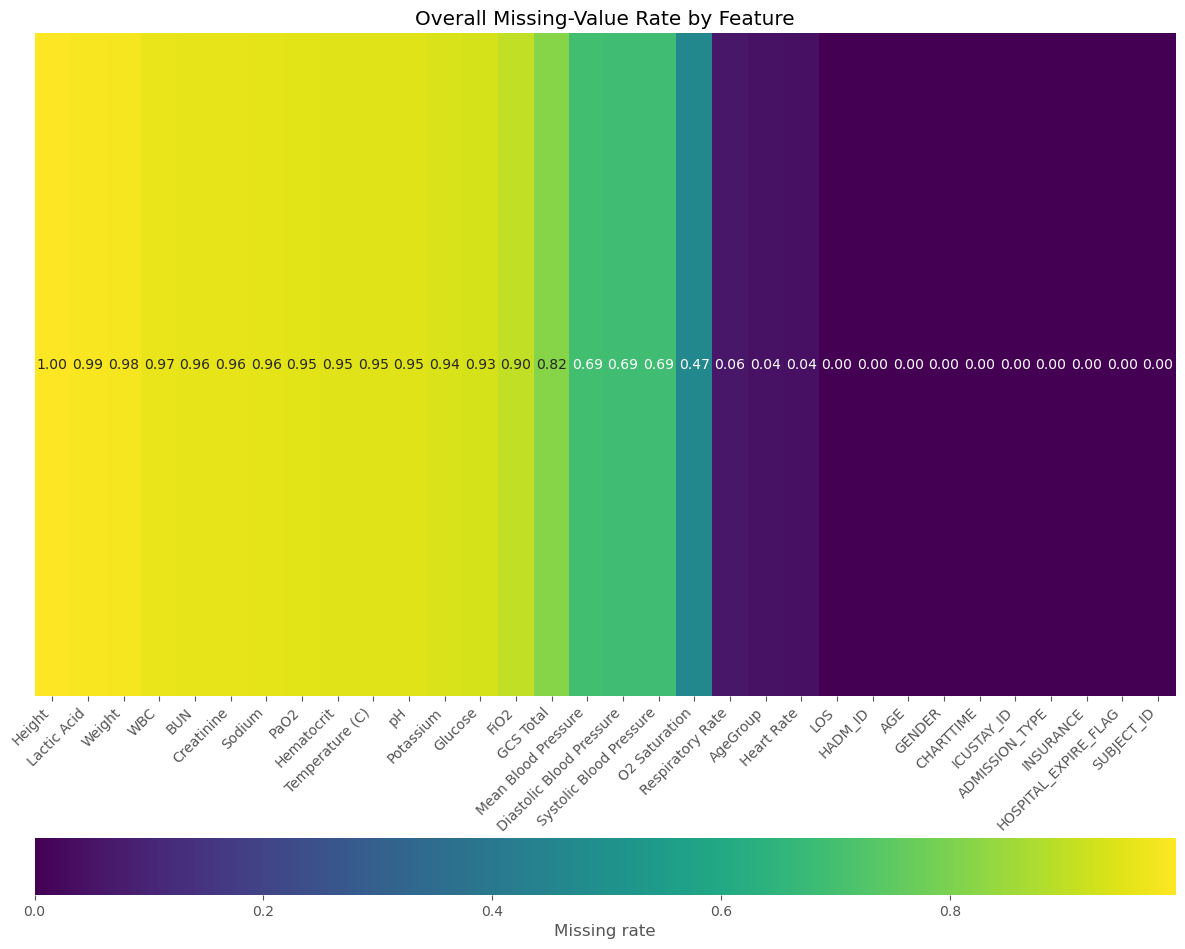

In [430]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1) compute missing‐value rate for each column
missing_rate = data.isnull().mean().sort_values(ascending=False)

# 2) plot as a 1×N heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    missing_rate.to_frame().T,       # turn Series into 1×N DataFrame
    annot=True,                      # show the numeric rates
    fmt=".2f",                       # two decimal places
    cmap="viridis",                  # or any other seaborn/matplotlib palette
    cbar_kws={"orientation": "horizontal", "label": "Missing rate"}
)
plt.yticks([], [])                   # hide the single y‐tick
plt.xticks(rotation=45, ha="right")  # rotate variable names
plt.title("Overall Missing‐Value Rate by Feature")
plt.tight_layout()
plt.show()


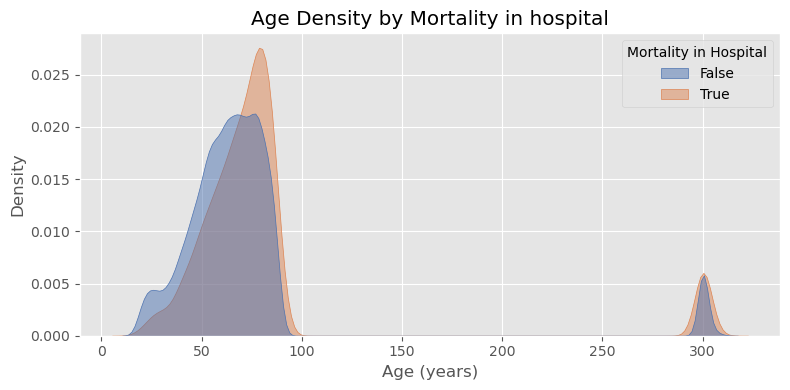

In [431]:
fig, ax = plt.subplots(figsize=(8,4))
sns.kdeplot(
    data=data,
    x='AGE',
    hue='HOSPITAL_EXPIRE_FLAG',
    common_norm=False,
    fill=True,
    alpha=0.5,
    palette=['#4c72b0','#dd8452'],
    ax=ax
)

leg = ax.get_legend()
for txt, new_label in zip(leg.texts, ['False','True']):
    txt.set_text(new_label)


leg.set_title('Mortality in Hospital')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Density')
ax.set_title('Age Density by Mortality in hospital')
plt.tight_layout()
plt.show()


/var/folders/rr/7lt3z7lx0dv_6xh6d53km6980000gn/T/ipykernel_12459/1903139909.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


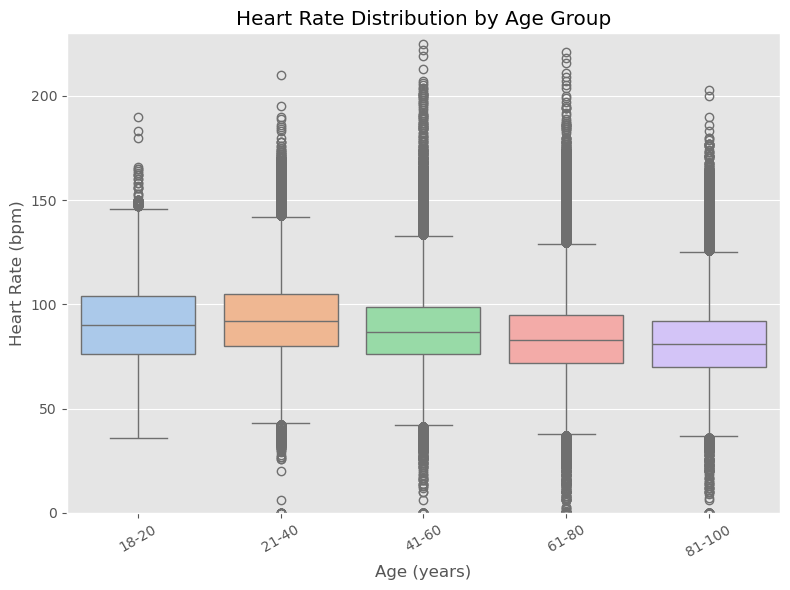

In [432]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x='AgeGroup',
    y='Heart Rate',
    data=data,
    palette='pastel'
)

plt.ylim(0, 230)
plt.xlabel('Age (years)')
plt.ylabel('Heart Rate (bpm)')
plt.title('Heart Rate Distribution by Age Group')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()



**Distribution of Oxygen Saturation**

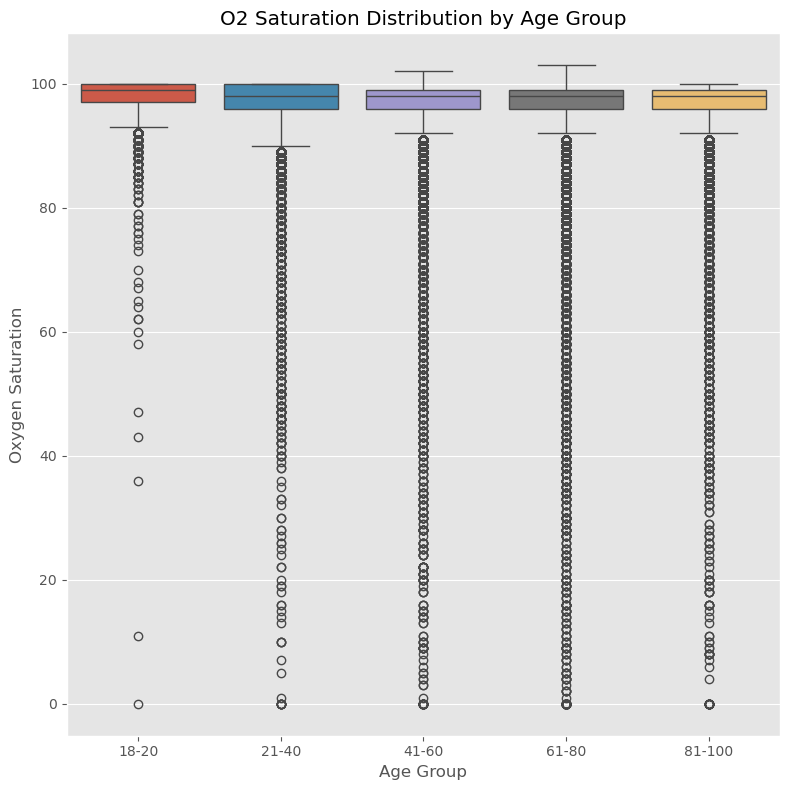

In [433]:
fig, ax = plt.subplots(figsize=(8,8))
sns.boxplot(
    data=data,
    x = "AgeGroup",
    y= 'O2 Saturation',
    hue = "AgeGroup",
    legend = False,
    ax=ax
)


ax.set_xlabel('Age Group')
ax.set_ylabel('Oxygen Saturation')
ax.set_title('O2 Saturation Distribution by Age Group')
plt.tight_layout()
plt.show()


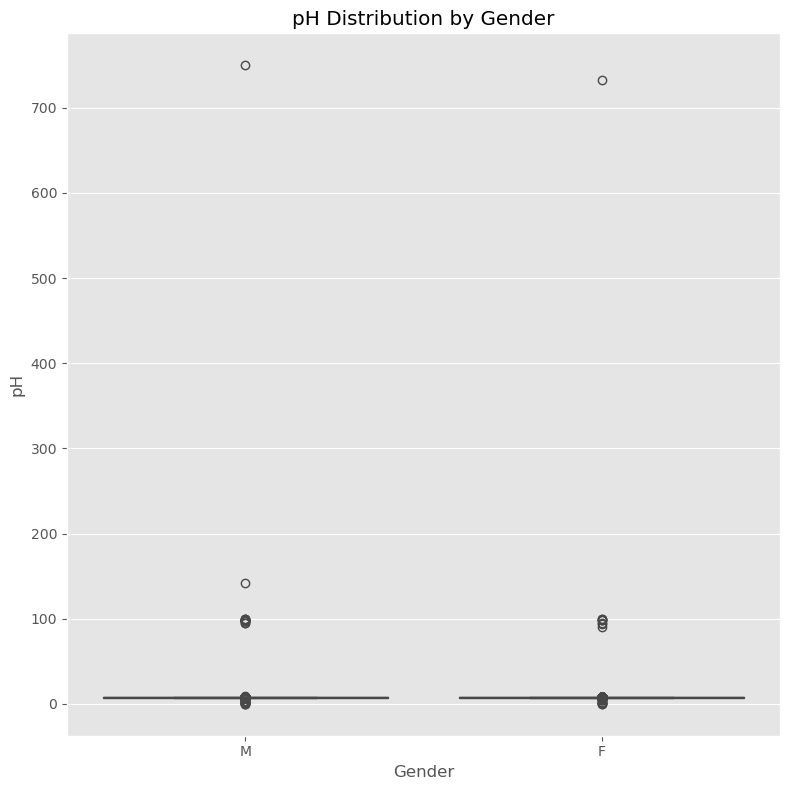

In [434]:
fig, ax = plt.subplots(figsize=(8,8))
sns.boxplot(
    data=data,
    x = "GENDER",
    y = 'pH',
    hue = "GENDER",
    legend = False,
    ax=ax
)


ax.set_xlabel('Gender')
ax.set_ylabel('pH')
ax.set_title('pH Distribution by Gender')
plt.tight_layout()
plt.show()

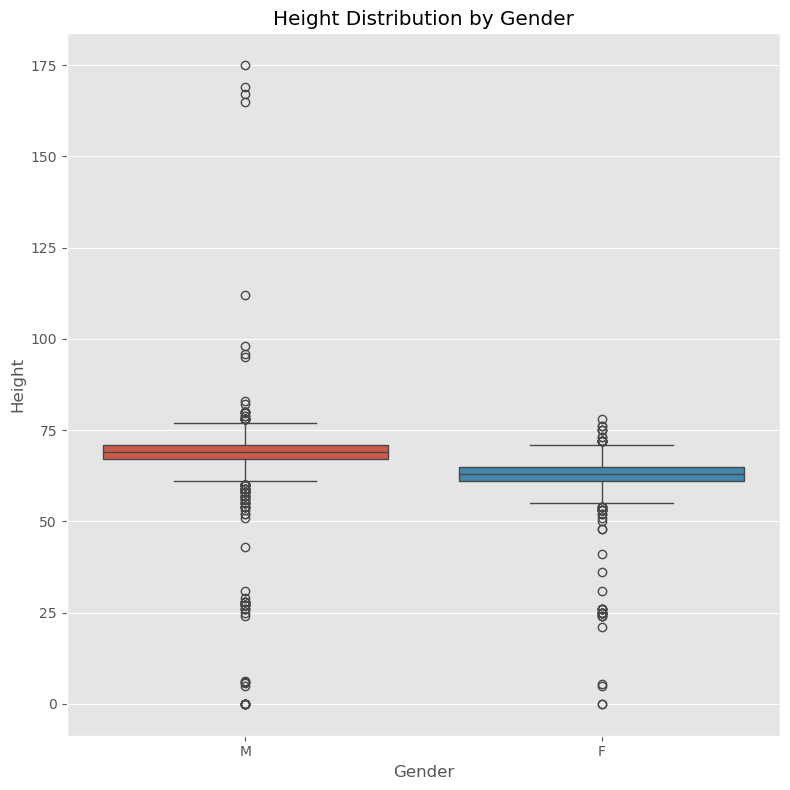

In [435]:
fig, ax = plt.subplots(figsize=(8,8))
sns.boxplot(
    data=data,
    x = "GENDER",
    y = 'Height',
    hue = "GENDER",
    legend = False,
    ax=ax
)


ax.set_xlabel('Gender')
ax.set_ylabel('Height')
ax.set_title('Height Distribution by Gender')
plt.tight_layout()
plt.show()

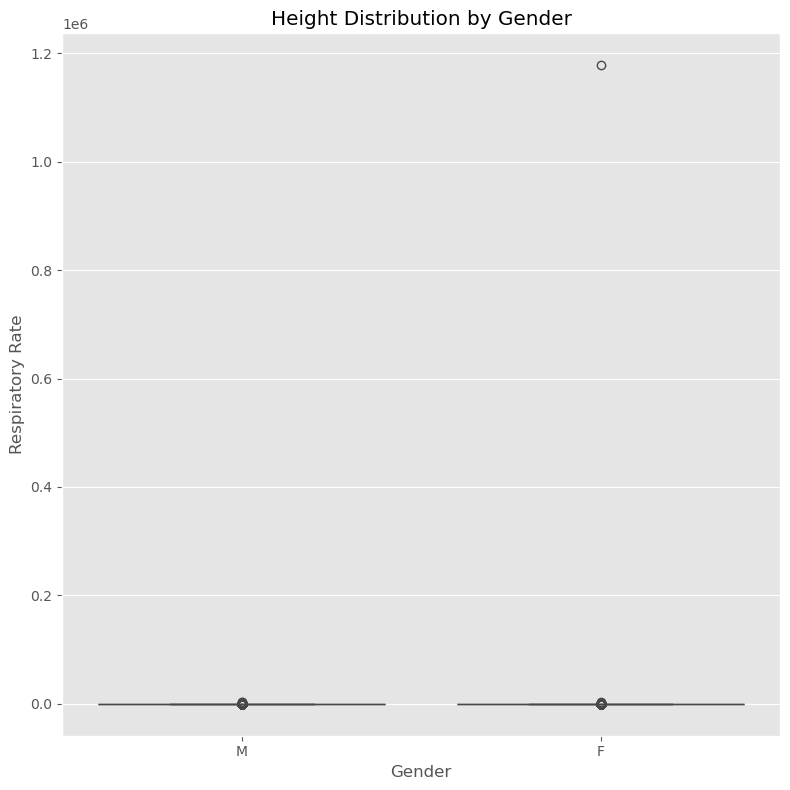

In [436]:
fig, ax = plt.subplots(figsize=(8,8))
sns.boxplot(
    data=data,
    x = "GENDER",
    y = 'Respiratory Rate',
    hue = "GENDER",
    legend = False,
    ax=ax
)

ax.set_xlabel('Gender')
ax.set_ylabel('Respiratory Rate')
ax.set_title('Height Distribution by Gender')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Repiratory Rate before data processing')

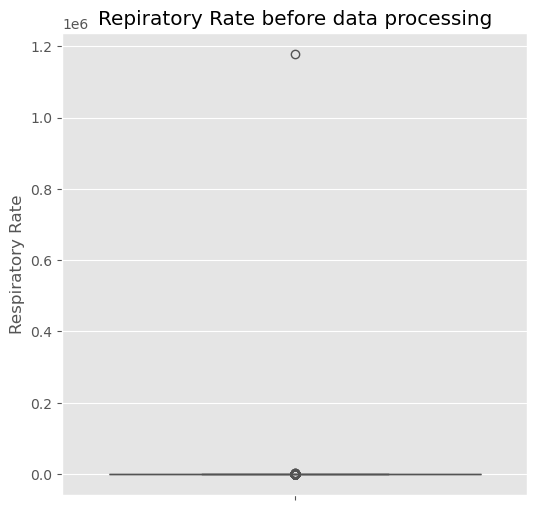

In [437]:
plt.figure(figsize=(6,6))
sns.boxplot(y = "Respiratory Rate", data = data)

plt.title("Repiratory Rate before data processing")

Text(0.5, 1.0, 'Body Temperature (C) of patient before data processing')

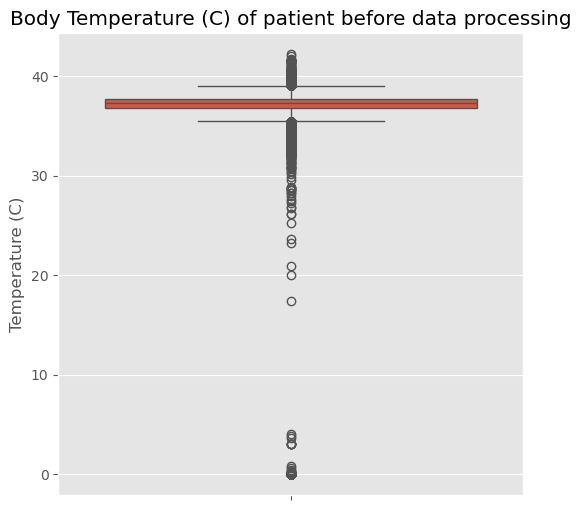

In [438]:
plt.figure(figsize=(6,6))
sns.boxplot(y = "Temperature (C)", data = data)

plt.title("Body Temperature (C) of patient before data processing")

Text(0.5, 1.0, 'Mean Blood Pressure of patient before data processing')

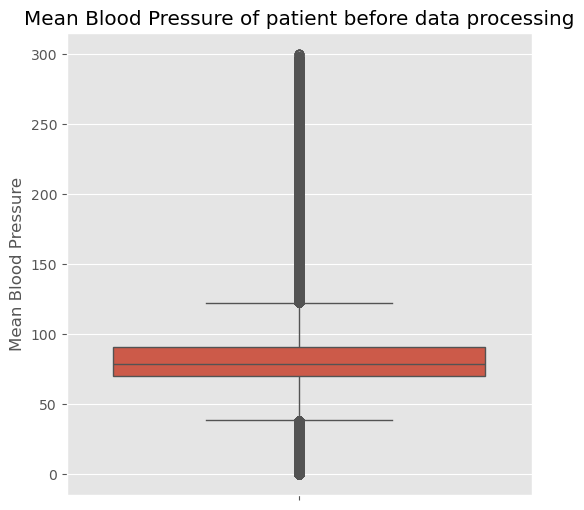

In [439]:
plt.figure(figsize=(6,6))
sns.boxplot(y = "Mean Blood Pressure", data = data)

plt.title("Mean Blood Pressure of patient before data processing")

Text(0.5, 1.0, 'Systolic Blood Pressure of patients before data processing')

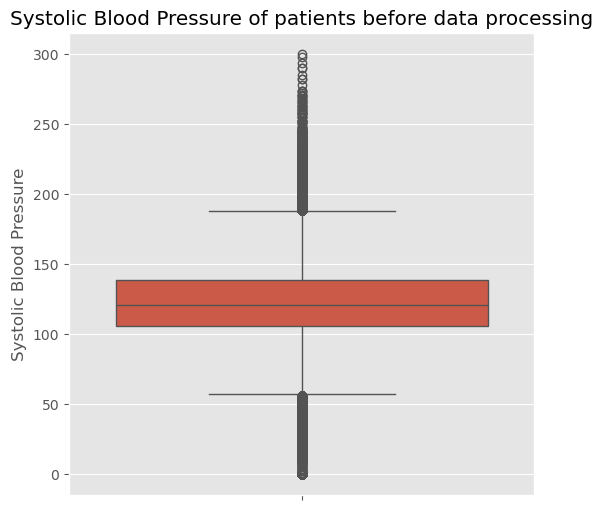

In [440]:
plt.figure(figsize=(6,6))
sns.boxplot(y = "Systolic Blood Pressure", data = data)

plt.title("Systolic Blood Pressure of patients before data processing")

Text(0.5, 1.0, 'Diastolic Blood Pressure of patients before data processing')

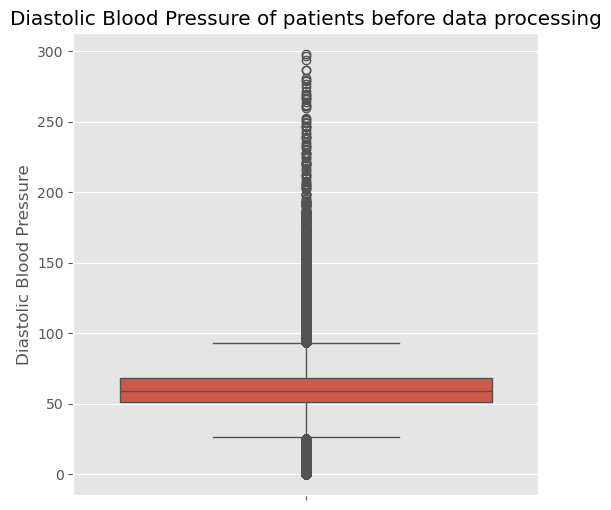

In [441]:
plt.figure(figsize=(6,6))
sns.boxplot(y = "Diastolic Blood Pressure", data = data)

plt.title("Diastolic Blood Pressure of patients before data processing")

Text(0.5, 1.0, 'WBC of patients before data processing')

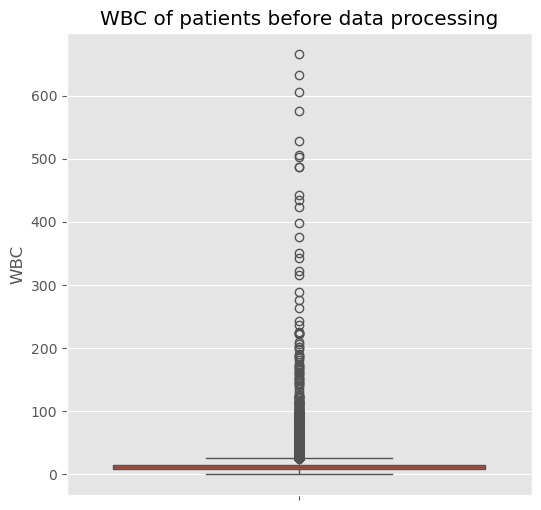

In [442]:
plt.figure(figsize=(6,6))
sns.boxplot(y = "WBC", data = data)

plt.title("WBC of patients before data processing")

Text(0.5, 1.0, 'Glucose of patients before data processing')

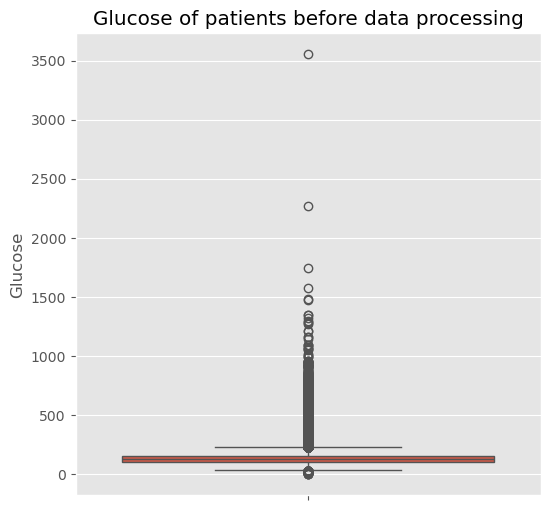

In [443]:
plt.figure(figsize=(6,6))
sns.boxplot(y = "Glucose", data = data)

plt.title("Glucose of patients before data processing")

Text(0.5, 1.0, 'Sodium of patients before data processing')

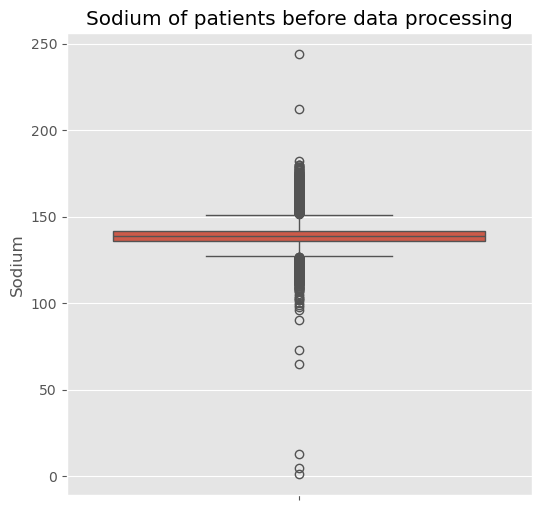

In [444]:
plt.figure(figsize=(6,6))
sns.boxplot(y = "Sodium", data = data)

plt.title("Sodium of patients before data processing")

Text(0.5, 1.0, 'Potassium of patients before data processing')

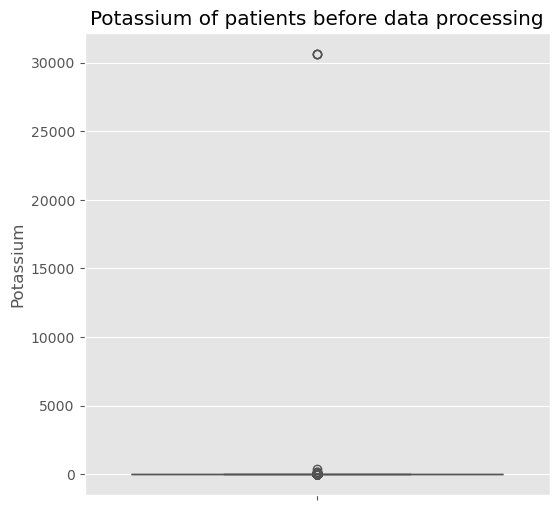

In [445]:
plt.figure(figsize=(6,6))
sns.boxplot(y = "Potassium", data = data)

plt.title("Potassium of patients before data processing")

Text(0.5, 1.0, 'Creatinine of patients before data processing')

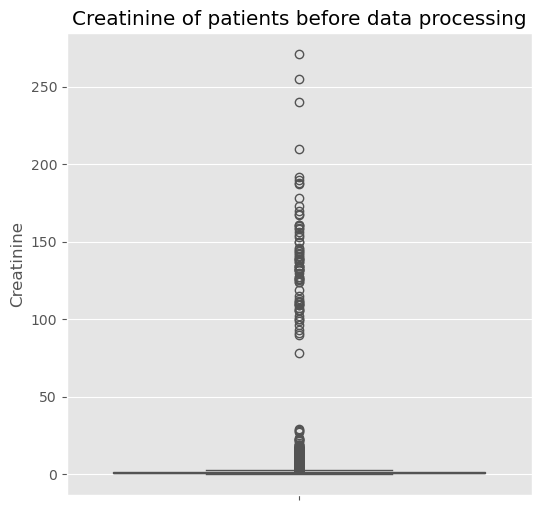

In [446]:
plt.figure(figsize=(6,6))
sns.boxplot(y = "Creatinine", data = data)

plt.title("Creatinine of patients before data processing")

Text(0.5, 1.0, 'BUN of patients before data processing')

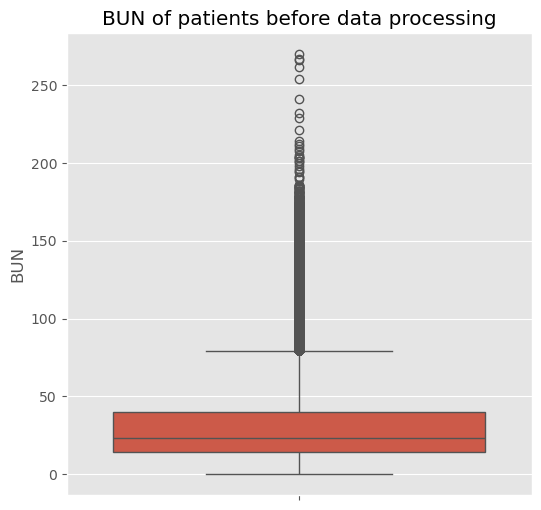

In [447]:
plt.figure(figsize=(6,6))
sns.boxplot(y = "BUN", data = data)

plt.title("BUN of patients before data processing")

Text(0.5, 1.0, 'Hematocrit of patients before data processing')

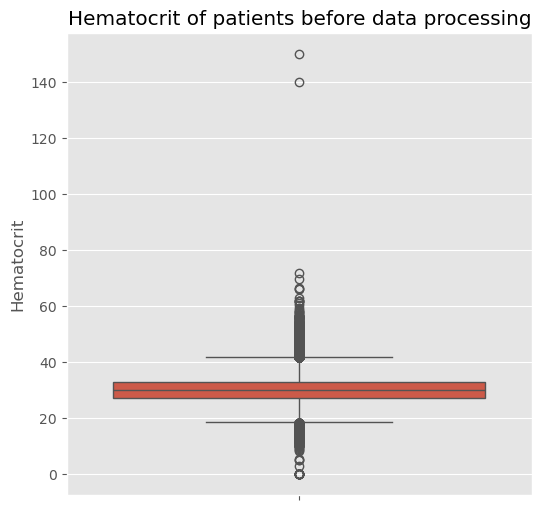

In [448]:
plt.figure(figsize=(6,6))
sns.boxplot(y = "Hematocrit", data = data)

plt.title("Hematocrit of patients before data processing")

Text(0.5, 1.0, 'Weight of patients before data processing')

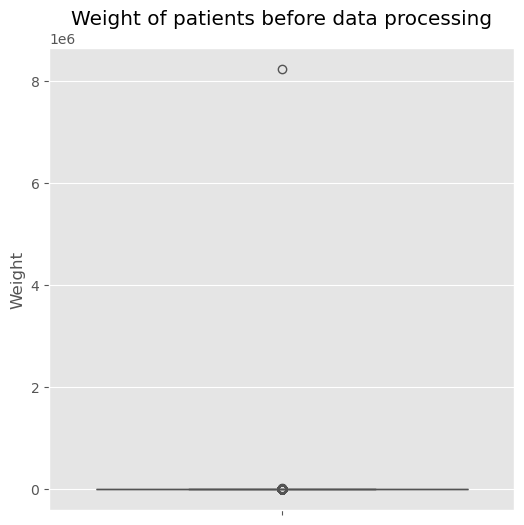

In [449]:
plt.figure(figsize=(6,6))
sns.boxplot(y = "Weight", data = data)

plt.title("Weight of patients before data processing")

Text(0.5, 1.0, 'GCS Total of patients before data processing')

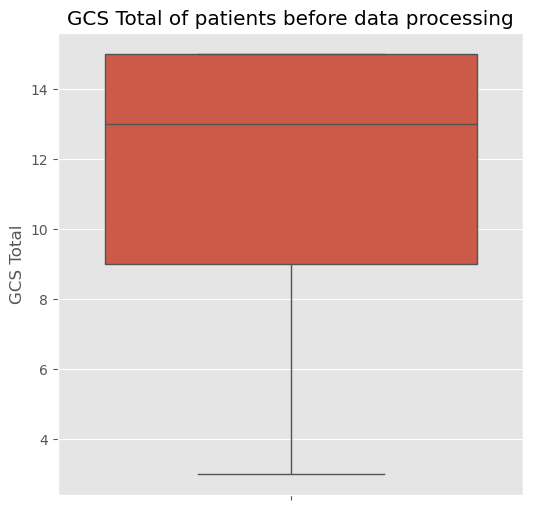

In [450]:
plt.figure(figsize=(6,6))
sns.boxplot(y = "GCS Total", data = data)

plt.title("GCS Total of patients before data processing")

Text(0.5, 1.0, 'Lactic Acid of patients before data processing')

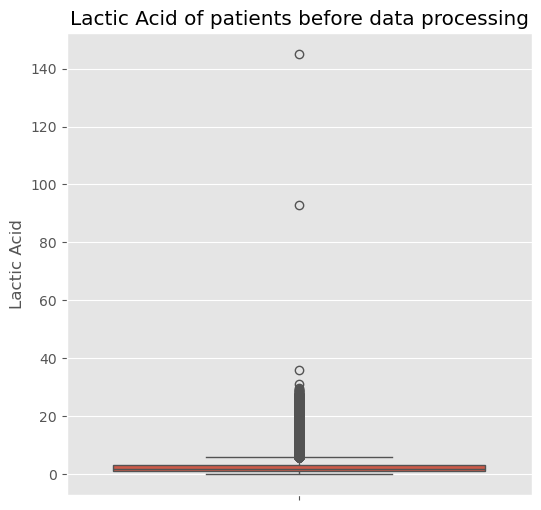

In [451]:
plt.figure(figsize=(6,6))
sns.boxplot(y = "Lactic Acid", data = data)

plt.title("Lactic Acid of patients before data processing")

Text(0.5, 1.0, 'FiO2 of patients before data processing')

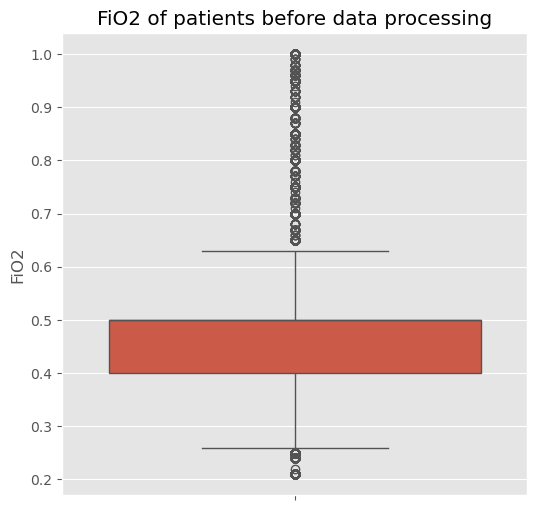

In [452]:
plt.figure(figsize=(6,6))
sns.boxplot(y = "FiO2", data = data)

plt.title("FiO2 of patients before data processing")

Text(0.5, 1.0, 'PaO2 of patients before data processing')

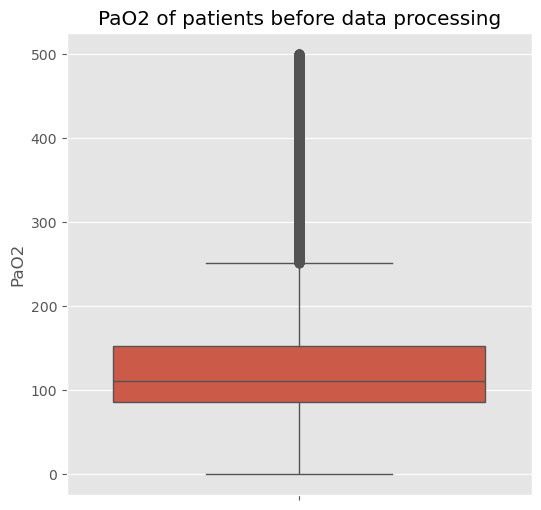

In [453]:
plt.figure(figsize=(6,6))
sns.boxplot(y = "PaO2", data = data)

plt.title("PaO2 of patients before data processing")

# **Data Imputation and Processing**

In [454]:
# Flag the rows where Height > 100 (likely cm)
cm_mask = data['Height'] < 100

# Convert those to inches
data.loc[cm_mask, 'Height'] = data.loc[cm_mask, 'Height'] * 0.453592


In [455]:
# Convert those to inches
data['Weight'] = data['Weight'] * 2.54

In [456]:
data = data[
    ((data["AGE"] <= 100) | data["AGE"].isna()) &
    ((data["O2 Saturation"].between(70, 100)) | data["O2 Saturation"].isna()) &
    ((data["pH"] <= 14) | data["pH"].isna()) &
    ((data["Height"] >= 100) | data["Height"].isna()) &
    ((data["Respiratory Rate"] <= 50) | data["Respiratory Rate"].isna()) &
    ((data["Systolic Blood Pressure"].between(60, 250)) | data["Systolic Blood Pressure"].isna()) &
    ((data["Diastolic Blood Pressure"].between(30, 150)) | data["Diastolic Blood Pressure"].isna()) &
    ((data["Mean Blood Pressure"].between(40, 180) | data["Mean Blood Pressure"].isna())) &
    ((data["Temperature (C)"].between(30, 42) | data["Temperature (C)"].isna())) &
    ((data["WBC"].between(30, 42) | data["WBC"].isna())) &
    ((data["Glucose"].between(10, 1000) | data["Glucose"].isna())) &
    ((data["Sodium"].between(100, 190) | data["Sodium"].isna())) &
    ((data["Potassium"].between(2, 10) | data["Potassium"].isna())) &
    ((data["Creatinine"].between(0.1, 30) | data["Creatinine"].isna())) &
    ((data["BUN"].between(1, 150) | data["BUN"].isna())) &
    ((data["Hematocrit"].between(10, 70) | data["Hematocrit"].isna())) &
    ((data["Weight"].between(10, 300) | data["Weight"].isna())) &
    ((data["Lactic Acid"].between(0.1, 20) | data["Lactic Acid"].isna())) &
    ((data["FiO2"].between(0.21, 1) | data["FiO2"].isna())) &
    ((data["PaO2"].between(20, 500) | data["PaO2"].isna())) &
    ((data["Heart Rate"] >= 0) | data["AGE"].isna())

]


First, I drop those records which has no value in Length of Stay

In [457]:
data = data.dropna(subset=["LOS"])

Second, I fill the empty value in heart rate with interpolate method

In [458]:
data['Heart Rate'] = data['Heart Rate'].interpolate(method='linear', limit_direction='both')

GCS Total with forwarf fill, and for those still has NaN value, I fill it with 15 which stand for full concious.

In [459]:
data['GCS Total'] = data['GCS Total'].ffill()

In [460]:
data["GCS Total"] = data["GCS Total"].fillna(15)

pH

In [461]:
data['pH'] = data['pH'].interpolate(method='linear', limit=4, limit_direction='both')
data['pH'] = data['pH'].round(1)

In [462]:
data['pH'] = data['pH'].fillna(7.4)

White Blood Cell

In [463]:
data['WBC'] = (
    data.groupby('SUBJECT_ID')['WBC']
    .transform(lambda x: x.fillna(method='ffill', limit=24))
)

/var/folders/rr/7lt3z7lx0dv_6xh6d53km6980000gn/T/ipykernel_12459/1193530138.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .transform(lambda x: x.fillna(method='ffill', limit=24))


In [464]:
data['WBC'] = (
    data.groupby('ICUSTAY_ID')['WBC']
    .transform(lambda x: x.interpolate(method='linear', limit=6, limit_direction='both'))
)

In [465]:
data['WBC'] = data['WBC'].fillna(7.5)

O2 Saturation

In [466]:
data['O2 Saturation'] = (
    data.groupby('ICUSTAY_ID')['O2 Saturation']
    .transform(lambda x: x.interpolate(method='linear', limit=6, limit_direction='both'))
)

In [467]:
data['O2 Saturation'] = data['O2 Saturation'].fillna(data['O2 Saturation'].mean())

In [468]:
data['O2 Saturation'] = data['O2 Saturation'].round(0)

Respiratory Rate

First, I fill the Null value by interpolate which group by ICUSTAY_ID

In [469]:
data["Respiratory Rate"] = (
    data.groupby("ICUSTAY_ID")["Respiratory Rate"]
    .transform(lambda x: x.interpolate(method="linear", limit=6, limit_direction="both"))
)

Than i fill the laft over null value with mean of Respiratory Rate

In [470]:
data["Respiratory Rate"] = data["Respiratory Rate"].fillna(data["Respiratory Rate"].mean())

Systolic Blood Pressure and Distolic Blood Pressure

In [471]:
data['Systolic Blood Pressure'] = (
    data.groupby('ICUSTAY_ID')['Systolic Blood Pressure']
    .transform(lambda x: x.interpolate(method='linear', limit=3, limit_direction='both')))

In [472]:
data['Diastolic Blood Pressure'] = (
    data.groupby('ICUSTAY_ID')['Diastolic Blood Pressure']
    .transform(lambda x: x.interpolate(method='linear', limit=3, limit_direction='both')))

In [473]:
import numpy as np
from scipy.stats import truncnorm

# 1) define your “normal” parameters
sbp_low, sbp_high = 90, 120
mean, sd = 110, 10
a, b = (sbp_low - mean) / sd, (sbp_high - mean) / sd

# 2) mask and draw
mask = data['Systolic Blood Pressure'].isna()
n_missing = mask.sum()
draws = truncnorm(a, b, loc=mean, scale=sd).rvs(n_missing)

# 3) assign
data.loc[mask, 'Systolic Blood Pressure'] = draws


In [474]:
import numpy as np
from scipy.stats import truncnorm

# 1) define your “normal” parameters for DBP
dbp_low, dbp_high = 60, 80
mean_dbp, sd_dbp = 75, 7
a_dbp, b_dbp = (dbp_low - mean_dbp) / sd_dbp, (dbp_high - mean_dbp) / sd_dbp

# 2) mask and draw as many samples as there are missing DBPs
mask_dbp = data['Diastolic Blood Pressure'].isna()
n_missing_dbp = mask_dbp.sum()
draws_dbp = truncnorm(a_dbp, b_dbp, loc=mean_dbp, scale=sd_dbp).rvs(n_missing_dbp)

# 3) assign back into your DataFrame
data.loc[mask_dbp, 'Diastolic Blood Pressure'] = draws_dbp


Mean Blood Pressure

In [475]:
mask = (
    data['Mean Blood Pressure'].isnull() &
    data['Systolic Blood Pressure'].notnull() &
    data['Diastolic Blood Pressure'].notnull()
)

data.loc[mask, 'Mean Blood Pressure'] = (
    data.loc[mask, 'Systolic Blood Pressure'] + 2 * data.loc[mask, 'Diastolic Blood Pressure']
) / 3

PaO2

In [476]:
import numpy as np

def estimate_pao2(spo2):
    if np.isnan(spo2):
        return np.nan
    elif spo2 < 91:
        return (spo2 - 30) * 1.7
    elif spo2 <= 98:
        return -27.74 * np.log(100 - spo2) + 100
    else:
        return 105  # reasonable upper cap


In [477]:
import numpy as np

data['PaO2_estimated'] = data['O2 Saturation'].apply(estimate_pao2)

In [478]:
data['PaO2'] = data['PaO2'].fillna(data['PaO2_estimated'])

In [479]:
data = data.drop(columns="PaO2_estimated", axis = 1)

FiO2

In [480]:
data['FiO2'].mean()

0.4989267235675529

In [481]:
data["FiO2"] = (
    data.groupby("ICUSTAY_ID")["FiO2"]
    .transform(lambda x: x.interpolate(method="linear", limit=6, limit_direction="both"))
)

FiO2 value of 0.21 means the patient is breathing on one's own.

In [482]:
data["FiO2"] = data['FiO2'].fillna(0.21)

In [483]:
data["FiO2"].mean()

0.31446195963110496

Lactic Acid

In [484]:
data["Lactic Acid"] = (
    data.groupby("ICUSTAY_ID")["Lactic Acid"]
    .transform(lambda x: x.interpolate(method="linear", limit=6, limit_direction="both"))
)

In [485]:
import numpy as np

na_mask = data['Lactic Acid'].isna()

random_vals = pd.Series(
    np.random.uniform(0.5, 2.0, size=na_mask.sum()),
    index=data.loc[na_mask].index
)

# Use fillna with a Series (not ndarray)
data['Lactic Acid'] = data['Lactic Acid'].fillna(random_vals)


Temperature

In [486]:
data["Temperature (C)"] = (
    data.groupby("ICUSTAY_ID")["Temperature (C)"]
    .transform(lambda x: x.interpolate(method="linear", limit=6, limit_direction="both"))
)

In [487]:
import numpy as np

# Generate random values only for rows where Lactic Acid is missing
na_mask = data['Temperature (C)'].isna()

# Create a Series of random values with the same index as missing values
random_vals = pd.Series(
    np.random.uniform(36.5, 37.2, size=na_mask.sum()),
    index=data.loc[na_mask].index
)

# Use fillna with a Series (not ndarray)
data['Temperature (C)'] = data['Temperature (C)'].fillna(random_vals)

Glucose

In [488]:
data["Glucose"] = (
    data.groupby("ICUSTAY_ID")["Glucose"]
    .transform(lambda x: x.interpolate(method="linear", limit=6, limit_direction="both"))
)

I used random value range between 72 and 99 which is the average glucose range for adult

In [489]:
import numpy as np

# Generate random values only for rows where Lactic Acid is missing
na_mask = data['Glucose'].isna()

# Create a Series of random values with the same index as missing values
random_vals = pd.Series(
    np.random.uniform(72, 99, size=na_mask.sum()),
    index=data.loc[na_mask].index
)

# Use fillna with a Series (not ndarray)
data['Glucose'] = data['Glucose'].fillna(random_vals)

Height

In [490]:
# Step 1: for each patient, grab their first non-null height
first_height = data.groupby("SUBJECT_ID")["Height"].transform("first")

# Step 2: fill missing Heights with that per-patient first_height
data["Height"] = data["Height"].fillna(first_height)


In [491]:
# Create a mask only for male rows
male = data["GENDER"] == "M"

# For those rows, group by Subject_ID and fillna to 175.3
data.loc[male, "Height"] = (
    data.loc[male]
    .groupby("SUBJECT_ID")["Height"]
    .transform(lambda s: s.fillna(175.3))
)

In [492]:
# Create a mask only for male rows
male = data["GENDER"] == "F"

# For those rows, group by Subject_ID and fillna to 175.3
data.loc[male, "Height"] = (
    data.loc[male]
    .groupby("SUBJECT_ID")["Height"]
    .transform(lambda s: s.fillna(161.3))
)

Weight

In [493]:
# Step 1: for each patient, grab their first non-null height
first_height = data.groupby("SUBJECT_ID")["Weight"].transform("first")

# Step 2: fill missing Heights with that per-patient first_height
data["Weight"] = data["Weight"].fillna(first_height)

In [494]:
# Create a mask only for male rows
male = data["GENDER"] == "M"

fill_min, fill_max = 76.0, 90.0

data.loc[male, "Weight"] = (
    data.loc[male]
    .groupby("SUBJECT_ID")["Weight"]
    .transform(lambda s:s.fillna(np.random.uniform(fill_min, fill_max)))
)

In [495]:
# Create a mask only for male rows
female = data["GENDER"] == "F"

fill_min, fill_max = 68.0, 82.0

data.loc[female, "Weight"] = (
    data.loc[female]
    .groupby("SUBJECT_ID")["Weight"]
    .transform(lambda s:s.fillna(np.random.uniform(fill_min, fill_max)))
)

Sodiumn

In [496]:
data["Sodium"].mean()

138.93627330368128

In [497]:
data["Sodium"] = (
    data.groupby("ICUSTAY_ID")["Sodium"]
    .transform(lambda x: x.interpolate(method="linear", limit=6, limit_direction="both"))
)

normal range of blood sodium is 135-145 mmol/L

In [498]:
fill_min, fill_max = 135.0, 145.0

data["Sodium"] = data["Sodium"].fillna(np.random.uniform(fill_min,fill_max))

In [499]:
data["Sodium"].mean()

142.99870984996443

Potassium

In [500]:
data["Potassium"].mean()

4.087917041254619

In [501]:
data["Potassium"] = (
    data.groupby("ICUSTAY_ID")["Potassium"]
    .transform(lambda x: x.interpolate(method="linear", limit=6, limit_direction="both"))
)

In [502]:
fill_min, fill_max = 3.5, 5.2

data["Potassium"] = data["Potassium"].fillna(np.random.uniform(fill_min,fill_max))

In [503]:
data["Potassium"].mean()

3.840921485743119

Creatinine

In [504]:
data["Creatinine"].mean()

1.7271991836380218

In [505]:
data["Creatinine"] = (
    data.groupby("ICUSTAY_ID")["Creatinine"]
    .transform(lambda x: x.interpolate(method="linear", limit=6, limit_direction="both"))
)

In [506]:
# Create a mask only for male rows
male = data["GENDER"] == "M"

fill_min, fill_max = 0.7, 1.3

# For those rows, group by Subject_ID and fillna to 175.3
data.loc[male, "Creatinine"] = (
    data.loc[male]
    .groupby("SUBJECT_ID")["Creatinine"]
    .transform(lambda s:s.fillna(np.random.uniform(fill_min, fill_max)))
)

In [507]:
# Create a mask only for male rows
female = data["GENDER"] == "F"

fill_min, fill_max = 0.6, 1.1

# For those rows, group by Subject_ID and fillna to 175.3
data.loc[female, "Creatinine"] = (
    data.loc[female]
    .groupby("SUBJECT_ID")["Creatinine"]
    .transform(lambda s:s.fillna(np.random.uniform(fill_min, fill_max)))
)

In [508]:
data["Creatinine"].mean()

0.9976812065832964

BUN

In [509]:
data['BUN'].mean()

34.65043864691576

In [510]:
data["BUN"] = (
    data.groupby("ICUSTAY_ID")["BUN"]
    .transform(lambda x: x.interpolate(method="linear", limit=6, limit_direction="both"))
)

In [511]:
fill_min, fill_max = 6, 24

data["BUN"] = data["BUN"].fillna(np.random.uniform(fill_min,fill_max))

In [512]:
data['BUN'].mean()

8.780616275937076

Hematocrit

In [513]:
data["Hematocrit"].mean()

29.937298711323635

In [514]:
data["Hematocrit"] = (
    data.groupby("ICUSTAY_ID")["Hematocrit"]
    .transform(lambda x: x.interpolate(method="linear", limit=6, limit_direction="both"))
)

In [515]:
fill_min, fill_max = 36, 54

data["Hematocrit"] = data["Hematocrit"].fillna(np.random.uniform(fill_min,fill_max))

In [516]:
data["Hematocrit"].mean()

37.17684518816273

In [517]:
data.isna().sum()

SUBJECT_ID                  0
HADM_ID                     0
ICUSTAY_ID                  0
CHARTTIME                   0
LOS                         0
GENDER                      0
AGE                         0
Heart Rate                  0
O2 Saturation               0
Respiratory Rate            0
Temperature (C)             0
Mean Blood Pressure         0
Systolic Blood Pressure     0
Diastolic Blood Pressure    0
WBC                         0
pH                          0
Glucose                     0
Sodium                      0
Potassium                   0
Creatinine                  0
BUN                         0
Hematocrit                  0
Height                      0
Weight                      0
GCS Total                   0
Lactic Acid                 0
FiO2                        0
PaO2                        0
ADMISSION_TYPE              0
INSURANCE                   0
HOSPITAL_EXPIRE_FLAG        0
AgeGroup                    0
dtype: int64

# **EDA**

Percentage of Gender

In [518]:
data

,SUBJECT_ID,HADM_ID,ICUSTAY_ID,CHARTTIME,LOS,GENDER,AGE,Heart Rate,O2 Saturation,Respiratory Rate,...,Height,Weight,GCS Total,Lactic Acid,FiO2,PaO2,ADMISSION_TYPE,INSURANCE,HOSPITAL_EXPIRE_FLAG,AgeGroup
0,3,145834,211552,2101-10-21 11:00:00,6.0646,M,77.0,88.0,98.0,9.0,...,175.3,269.240000,15.0,1.601220,0.40,80.772097,EMERGENCY,Medicare,0,61-80
1,3,145834,211552,2101-10-24 21:00:00,6.0646,M,77.0,86.0,98.0,17.0,...,175.3,269.240000,15.0,1.549035,0.40,80.772097,EMERGENCY,Medicare,0,61-80
2,3,145834,211552,2101-10-24 20:00:00,6.0646,M,77.0,85.0,99.0,17.0,...,175.3,269.240000,15.0,0.730116,0.40,105.000000,EMERGENCY,Medicare,0,61-80
3,3,145834,211552,2101-10-24 19:00:00,6.0646,M,77.0,84.0,100.0,18.0,...,175.3,269.240000,15.0,1.471546,0.40,105.000000,EMERGENCY,Medicare,0,61-80
4,3,145834,211552,2101-10-24 18:00:00,6.0646,M,77.0,88.0,100.0,17.0,...,175.3,269.240000,15.0,0.612001,0.40,105.000000,EMERGENCY,Medicare,0,61-80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3497830,99999,113369,246512,2117-12-31 14:00:00,1.1242,F,64.0,98.0,97.0,18.0,...,161.3,75.416445,4.0,0.764668,0.21,69.524495,ELECTIVE,Medicare,0,61-80
3497831,99999,113369,246512,2117-12-31 13:00:00,1.1242,F,64.0,94.0,97.0,15.0,...,161.3,75.416445,4.0,0.823122,0.21,69.524495,ELECTIVE,Medicare,0,61-80
3497833,99999,113369,246512,2118-01-01 13:00:00,1.1242,F,64.0,86.0,97.0,15.0,...,161.3,75.416445,4.0,1.818850,0.21,69.524495,ELECTIVE,Medicare,0,61-80
3497834,99999,113369,246512,2118-01-01 00:00:00,1.1242,F,64.0,100.0,97.0,21.0,...,161.3,75.416445,4.0,1.773556,0.21,69.524495,ELECTIVE,Medicare,0,61-80


In [519]:
# Number of distinct patients
num_patients = data["SUBJECT_ID"].nunique()
print(f"There are {num_patients} unique patients in the dataset.")


There are 31647 unique patients in the dataset.


<Figure size 800x800 with 0 Axes>

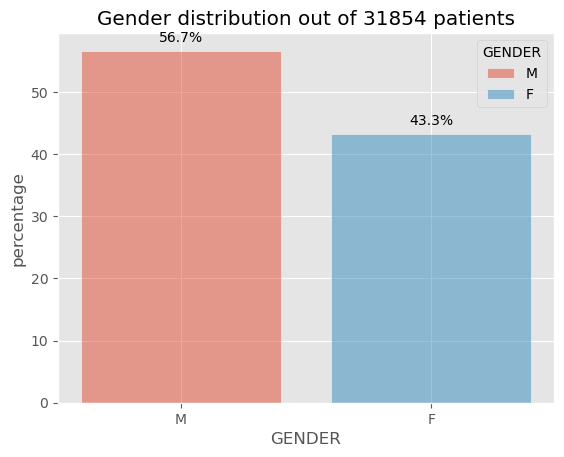

In [520]:
counts = data['GENDER'].value_counts()
total  = counts.sum()
percentages = counts / total * 100

plt.figure(figsize=(8,8))

fig, ax = plt.subplots()

sns.histplot(
    data=data,
    x="GENDER",
    hue="GENDER",
    stat = "percent",
    discrete=True,
    shrink=0.8
)


for i,(gender, pct) in enumerate(percentages.items()):
    ax.text(
        i,               # x coordinate: bar index (0 for first category, 1 for second)
        pct + 1,         # y coordinate: a little above the bar
        f"{pct:.1f}%",   # label: “xx.x%”
        ha='center',
        va='bottom'
    )


plt.ylabel("percentage")
plt.title("Gender distribution out of 31854 patients")
plt.show()


Age distribution

/var/folders/rr/7lt3z7lx0dv_6xh6d53km6980000gn/T/ipykernel_12459/2589292334.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = "GENDER", y = "AGE", data = data, palette='pastel')


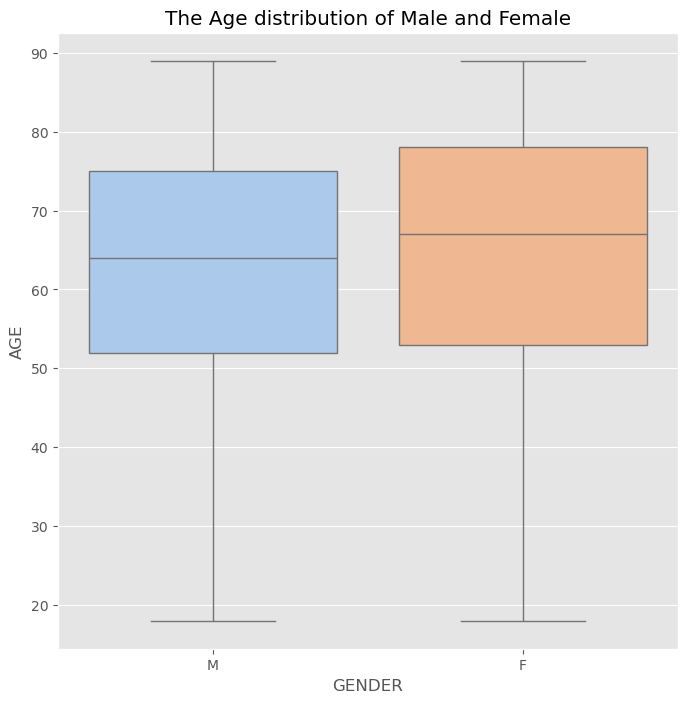

In [521]:
plt.figure(figsize=(8,8))

sns.boxplot(x = "GENDER", y = "AGE", data = data, palette='pastel')

plt.title("The Age distribution of Male and Female")

plt.show()

Text(0.5, 1.0, 'Age group distribution of Patients')

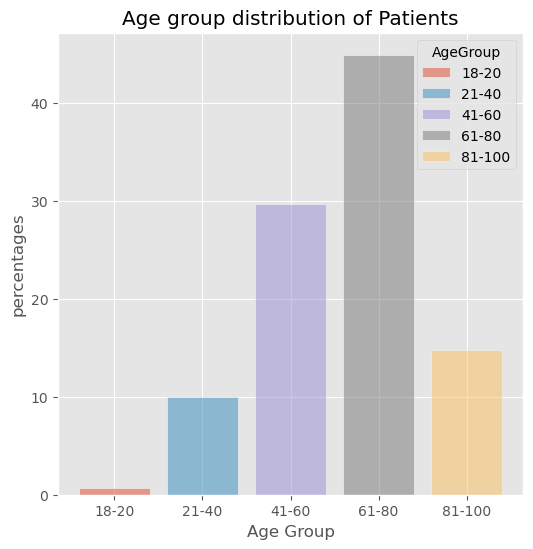

In [522]:
plt.figure(figsize=(6,6))

sns.histplot(x = 'AgeGroup', hue = "AgeGroup", data = data, stat = "percent",discrete=True, shrink=0.8)

plt.xlabel("Age Group")
plt.ylabel("percentages")
plt.title("Age group distribution of Patients")

Admission Type

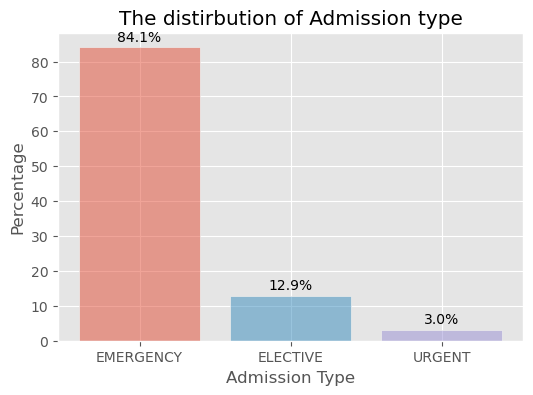

In [523]:
fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(x = "ADMISSION_TYPE", data = data, stat= "percent",discrete=True, shrink= 0.8, hue = "ADMISSION_TYPE", legend=False, ax=ax)
plt.xlabel("Admission Type")
plt.ylabel("Percentage")
plt.title("The distirbution of Admission type")


counts = data['ADMISSION_TYPE'].value_counts()
total  = counts.sum()
percentages = counts / total * 100

for i,(admission_type, pct) in enumerate(percentages.items()):
    ax.text(
        i,               # x coordinate: bar index (0 for first category, 1 for second)
        pct + 1,         # y coordinate: a little above the bar
        f"{pct:.1f}%",   # label: “xx.x%”
        ha='center',
        va='bottom'
    )

plt.show()

Insurance

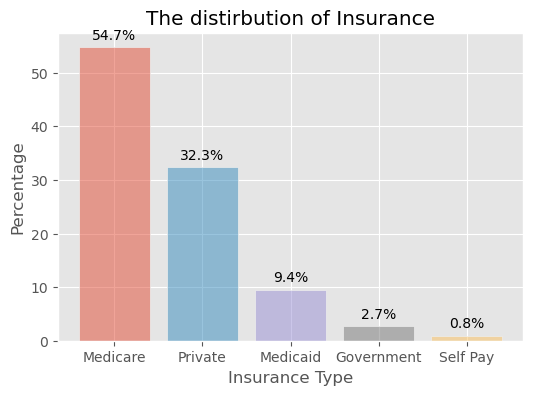

In [524]:
fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(x = "INSURANCE", data = data, stat= "percent",discrete=True, shrink= 0.8, hue = "INSURANCE", legend=False,ax=ax)
plt.xlabel("Insurance Type")
plt.ylabel("Percentage")
plt.title("The distirbution of Insurance")

counts = data['INSURANCE'].value_counts()
total  = counts.sum()
percentages = counts / total * 100

for i,(insurance, pct) in enumerate(percentages.items()):
    ax.text(
        i,               # x coordinate: bar index (0 for first category, 1 for second)
        pct + 1,         # y coordinate: a little above the bar
        f"{pct:.1f}%",   # label: “xx.x%”
        ha='center',
        va='bottom'
    )

plt.show()

/var/folders/rr/7lt3z7lx0dv_6xh6d53km6980000gn/T/ipykernel_12459/3410099350.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


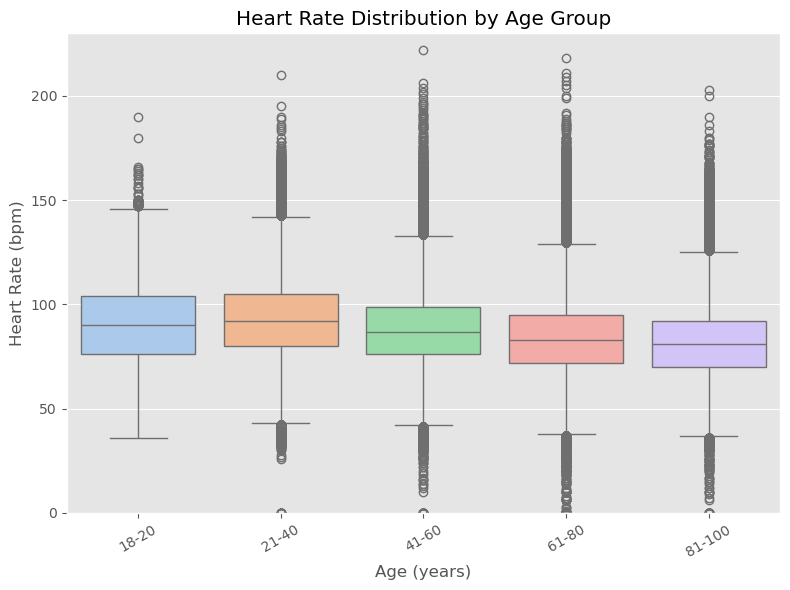

In [525]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x='AgeGroup',
    y='Heart Rate',
    data=data,
    palette='pastel'
)

plt.ylim(0, 230)
plt.xlabel('Age (years)')
plt.ylabel('Heart Rate (bpm)')
plt.title('Heart Rate Distribution by Age Group')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


Oxygen Saturation

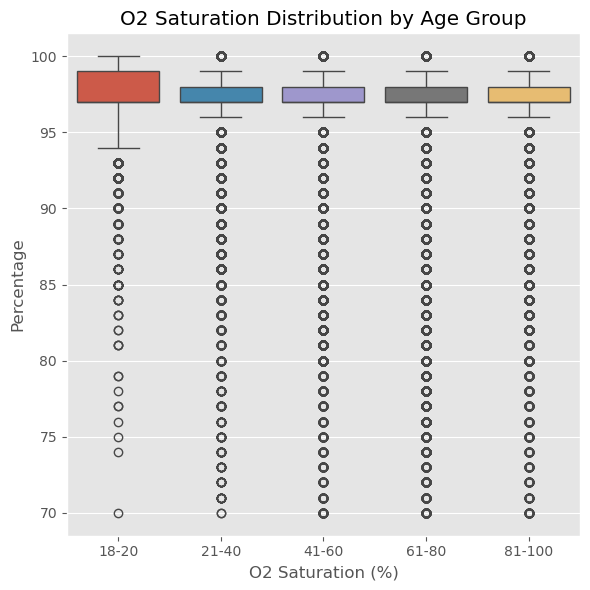

In [526]:
fig, ax = plt.subplots(figsize=(6,6))
sns.boxplot(
    data=data,
    x = "AgeGroup",
    y = 'O2 Saturation',
    hue='AgeGroup',
    ax=ax
)


ax.set_xlabel('O2 Saturation (%)')
ax.set_ylabel('Percentage')
ax.set_title('O2 Saturation Distribution by Age Group')
plt.tight_layout()
plt.show()

Blood Pressure By Age

Text(0.5, 1.0, 'Systolic Blood Pressure by age group')

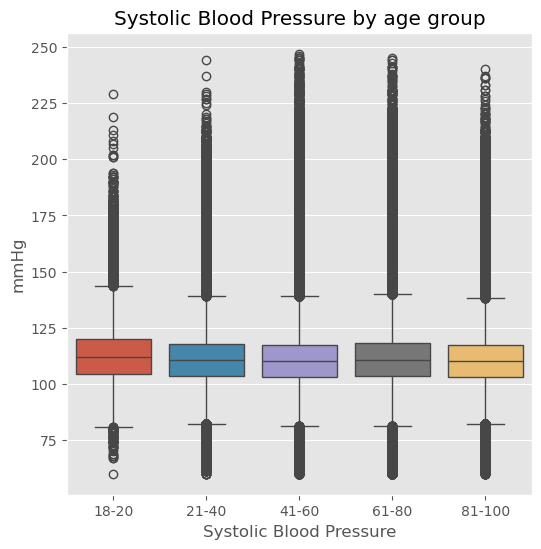

In [527]:
fig, ax = plt.subplots(figsize=(6,6))

sns.boxplot(
    data = data,
    x = "AgeGroup",
    y = "Systolic Blood Pressure",
    hue='AgeGroup',
    ax=ax
)

ax.set_xlabel("Systolic Blood Pressure")
ax.set_ylabel("mmHg")
ax.set_title("Systolic Blood Pressure by age group")

Text(0.5, 1.0, 'Diastolic Blood Pressure by age group')

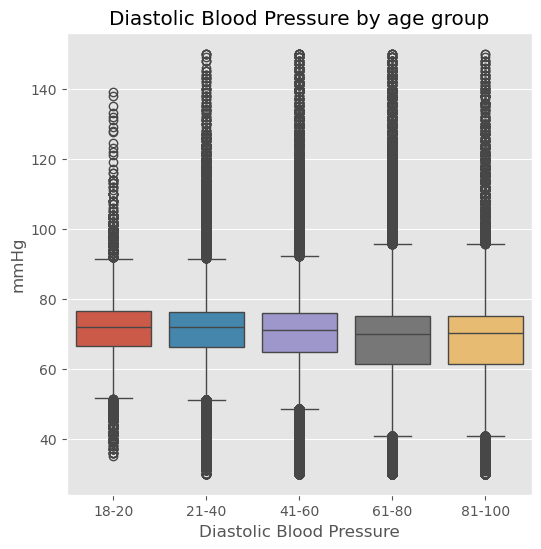

In [528]:
fig, ax = plt.subplots(figsize=(6,6))

sns.boxplot(
    data = data,
    x = "AgeGroup",
    y = "Diastolic Blood Pressure",
    hue='AgeGroup',
    ax=ax
)

ax.set_xlabel("Diastolic Blood Pressure")
ax.set_ylabel("mmHg")
ax.set_title("Diastolic Blood Pressure by age group")

Text(0.5, 1.0, 'Mean Blood Pressure by age group')

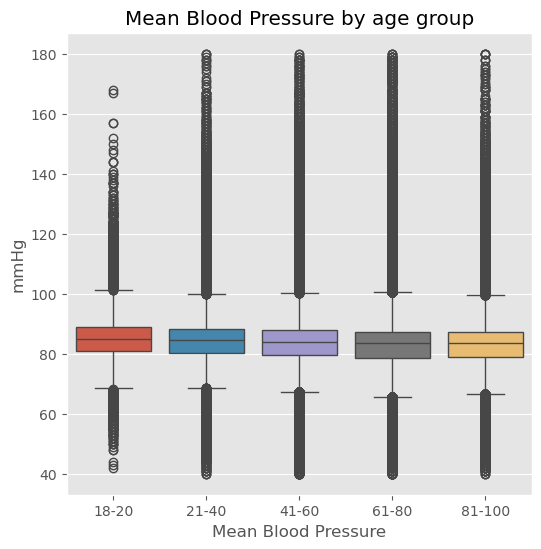

In [529]:
fig, ax = plt.subplots(figsize=(6,6))

sns.boxplot(
    data = data,
    x = "AgeGroup",
    y = "Mean Blood Pressure",
    hue='AgeGroup',
    ax=ax
)

ax.set_xlabel("Mean Blood Pressure")
ax.set_ylabel("mmHg")
ax.set_title("Mean Blood Pressure by age group")

Mortality in Hospital

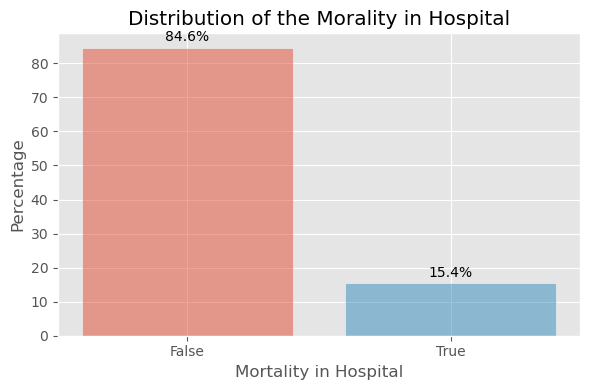

In [530]:
counts = data['HOSPITAL_EXPIRE_FLAG'].value_counts()
total  = counts.sum()
percentages = counts / total * 100


fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(
    data=data,
    x='HOSPITAL_EXPIRE_FLAG',
    discrete=True,       # ← key bit
    shrink=0.8,
    hue = "HOSPITAL_EXPIRE_FLAG",
    stat="percent",
    legend= False,
    ax=ax
)


for i,(mortality_inunit, pct) in enumerate(percentages.items()):
    ax.text(
        i,               # x coordinate: bar index (0 for first category, 1 for second)
        pct + 1,         # y coordinate: a little above the bar
        f"{pct:.1f}%",   # label: “xx.x%”
        ha='center',
        va='bottom'
    )


# Optional: force your x-ticks to 0 and 1
ax.set_xticks([0, 1])
ax.set_xticklabels(['False','True'])
ax.set_ylabel('Percentage')
ax.set_xlabel('Mortality in Hospital')
ax.set_title("Distribution of the Morality in Hospital")
plt.tight_layout()
plt.show()

**KDE for Mortality in hospital by age group**

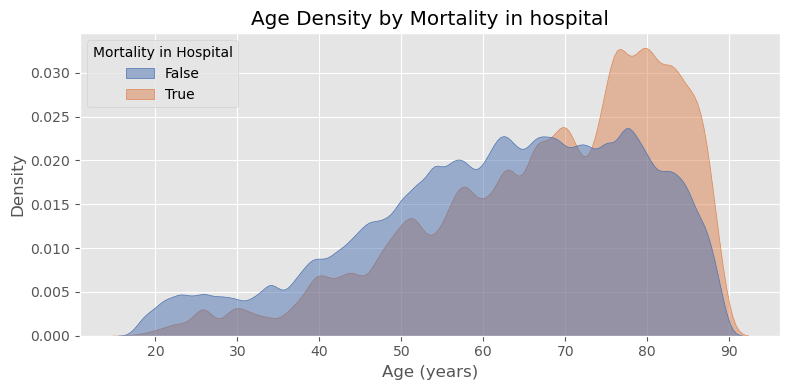

In [531]:
fig, ax = plt.subplots(figsize=(8,4))
sns.kdeplot(
    data=data,
    x='AGE',
    hue='HOSPITAL_EXPIRE_FLAG',
    common_norm=False,
    fill=True,
    alpha=0.5,
    palette=['#4c72b0','#dd8452'],
    ax=ax
)

leg = ax.get_legend()
for txt, new_label in zip(leg.texts, ['False','True']):
    txt.set_text(new_label)


leg.set_title('Mortality in Hospital')
leg.set_loc('upper left')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Density')
ax.set_title('Age Density by Mortality in hospital')
plt.tight_layout()
plt.show()

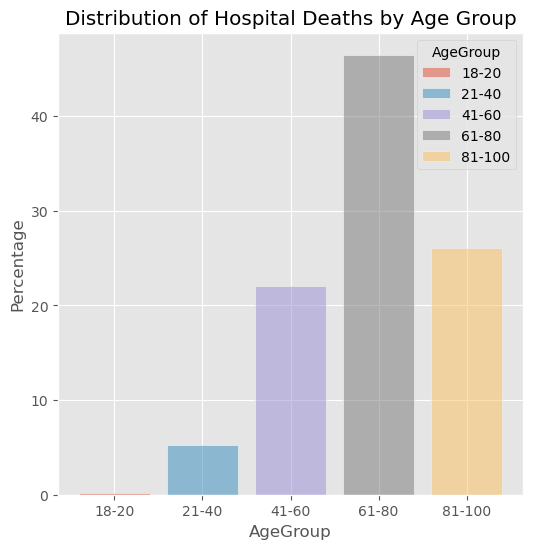

In [532]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter to patients who died in hospital
died_in_hospital = data[data["HOSPITAL_EXPIRE_FLAG"] == 1]

# Make sure you only count each patient once
# Replace 'PATIENT_ID' with your actual patient identifier column
died_in_hospital_unique = died_in_hospital.drop_duplicates(subset="SUBJECT_ID")

plt.figure(figsize=(6,6))
sns.histplot(
    x="AgeGroup",
    hue="AgeGroup",
    data=died_in_hospital_unique,
    stat = "percent",
    shrink=0.8,
    discrete=True
)

plt.ylabel('Percentage')
plt.title('Distribution of Hospital Deaths by Age Group')
plt.show()


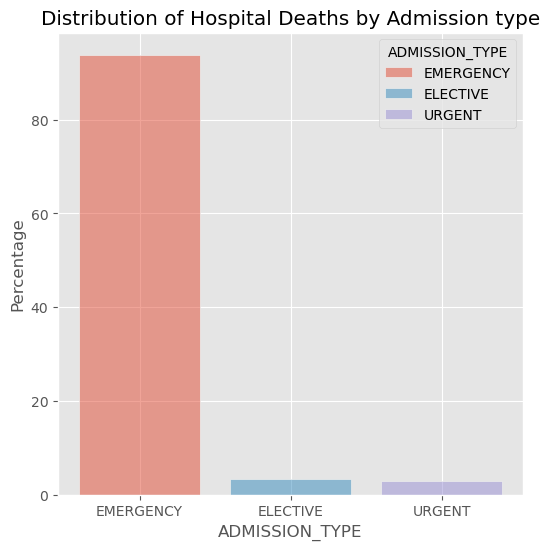

In [533]:
died_in_hospital = data[data["HOSPITAL_EXPIRE_FLAG"] == 1]


died_in_hospital_unique = died_in_hospital.drop_duplicates(subset="SUBJECT_ID")

plt.figure(figsize=(6,6))
sns.histplot(
    x="ADMISSION_TYPE",
    hue="ADMISSION_TYPE",
    data=died_in_hospital_unique,
    stat = "percent",
    shrink=0.8,
    discrete=True
)

plt.ylabel('Percentage')
plt.title('Distribution of Hospital Deaths by Admission type')
plt.show()


**Drop unrelavent data and encoding**

In [534]:
from sklearn.preprocessing import LabelEncoder

# list your categorical columns
cat_cols = ["ADMISSION_TYPE", "INSURANCE", "GENDER"]

label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    label_encoders[col] = le


In [535]:
data.to_csv("/Users/william/Desktop/ERP/data_multi.csv", index = False)

In [536]:
data = data.drop(["SUBJECT_ID","HADM_ID","ICUSTAY_ID","CHARTTIME","AgeGroup"], axis = 1)


**Correlation Heat Map**

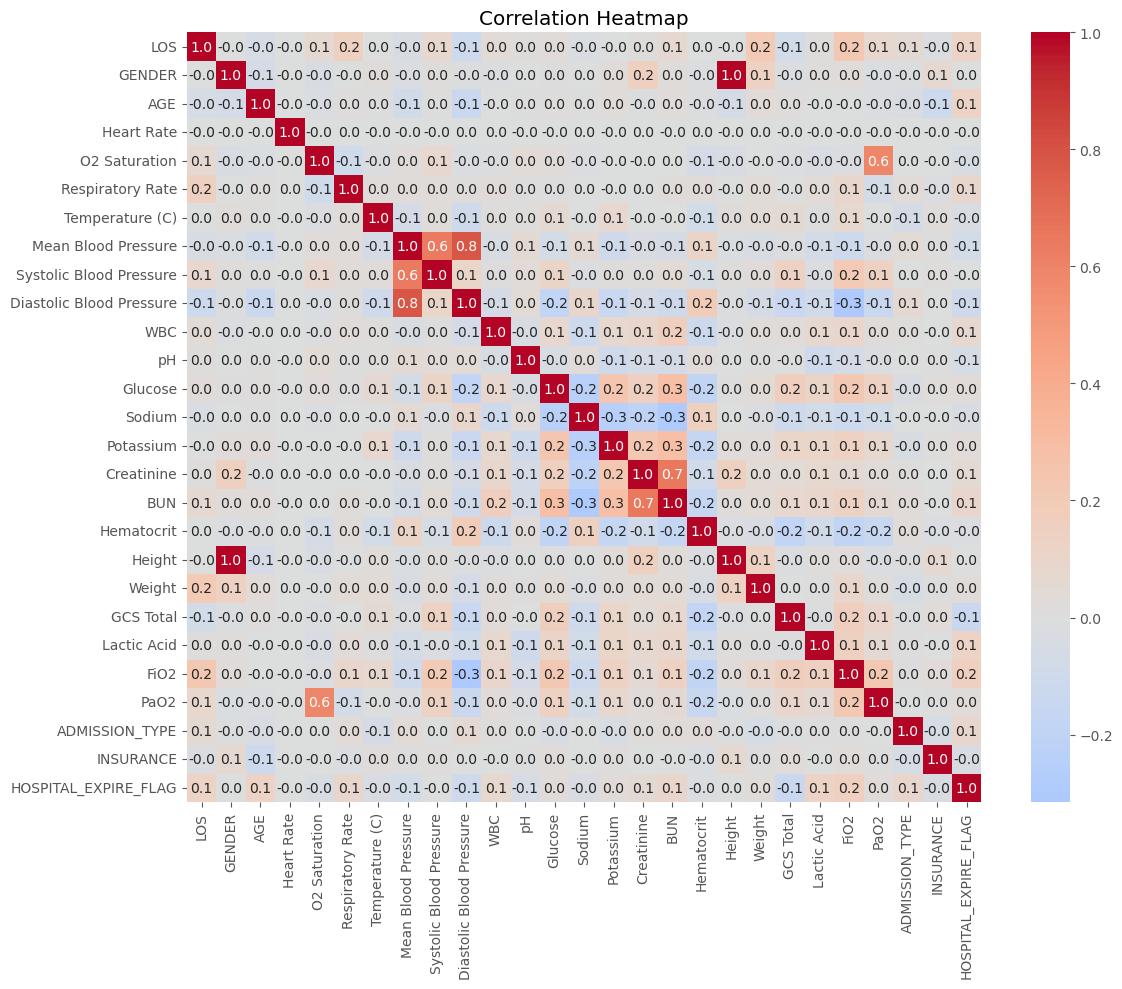

In [537]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
sns.heatmap(data.corr(), cmap='coolwarm', center=0, annot=True, fmt=".1f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


# **Feature Engineer**

In [538]:
X = data.drop(['HOSPITAL_EXPIRE_FLAG'], axis=1)

y = data[['HOSPITAL_EXPIRE_FLAG']]

In [539]:
X

,LOS,GENDER,AGE,Heart Rate,O2 Saturation,Respiratory Rate,Temperature (C),Mean Blood Pressure,Systolic Blood Pressure,Diastolic Blood Pressure,...,BUN,Hematocrit,Height,Weight,GCS Total,Lactic Acid,FiO2,PaO2,ADMISSION_TYPE,INSURANCE
0,6.0646,1,77.0,88.0,98.0,9.0,37.000000,78.000000,114.000000,62.000000,...,6.513191,38.312979,175.3,269.240000,15.0,1.601220,0.40,80.772097,1,2
1,6.0646,1,77.0,86.0,98.0,17.0,36.933333,79.041667,115.125000,61.000000,...,6.513191,38.312979,175.3,269.240000,15.0,1.549035,0.40,80.772097,1,2
2,6.0646,1,77.0,85.0,99.0,17.0,36.866667,78.750000,116.250000,60.000000,...,6.513191,38.312979,175.3,269.240000,15.0,0.730116,0.40,105.000000,1,2
3,6.0646,1,77.0,84.0,100.0,18.0,36.800000,78.458333,117.375000,59.000000,...,6.513191,38.312979,175.3,269.240000,15.0,1.471546,0.40,105.000000,1,2
4,6.0646,1,77.0,88.0,100.0,17.0,36.733333,90.719209,117.949251,77.104187,...,6.513191,38.312979,175.3,269.240000,15.0,0.612001,0.40,105.000000,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3497830,1.1242,0,64.0,98.0,97.0,18.0,37.174990,83.699528,110.534646,70.281969,...,6.513191,38.312979,161.3,75.416445,4.0,0.764668,0.21,69.524495,0,2
3497831,1.1242,0,64.0,94.0,97.0,15.0,37.030493,91.407209,115.528930,79.346348,...,6.513191,38.312979,161.3,75.416445,4.0,0.823122,0.21,69.524495,0,2
3497833,1.1242,0,64.0,86.0,97.0,15.0,36.847295,84.404711,107.511431,72.851351,...,6.513191,38.312979,161.3,75.416445,4.0,1.818850,0.21,69.524495,0,2
3497834,1.1242,0,64.0,100.0,97.0,21.0,36.587685,81.650256,92.062569,76.444099,...,6.513191,38.312979,161.3,75.416445,4.0,1.773556,0.21,69.524495,0,2


In [124]:
from sklearn.feature_selection import SelectKBest, SelectPercentile
from sklearn.feature_selection import chi2, f_classif, mutual_info_classif

##  Selecting Top 20 Best Features using SelectKBest class
kc = SelectKBest(score_func=chi2, k=20)
kf = SelectKBest(score_func=f_classif, k=20)
km = SelectKBest(score_func=mutual_info_classif, k=20)

kc_fit = kc.fit(X,y)
kf_fit = kf.fit(X,y)
km_fit = km.fit(X,y)

kc_scores = pd.DataFrame(kc_fit.scores_)  # Scores of features.
kf_scores = pd.DataFrame(kf_fit.scores_)  # Scores of features.
km_scores = pd.DataFrame(km_fit.scores_)  # Scores of features.
X_columns = pd.DataFrame(X.columns)

# Combine dataframes ...
featureScores = pd.concat([X_columns, kc_scores, kf_scores, km_scores], axis=1)
# Naming the dataframe's columns ...
featureScores.columns = ['Specs', 'chi2_Scores', 'f-test_Scores',
                         'mutual_info_scores']
featureScores

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,Specs,chi2_Scores,f-test_Scores,mutual_info_scores
0,LOS,919747.018194,62708.216473,0.366699
1,GENDER,21.527101,49.673640,0.094219
2,AGE,143294.936279,34046.324632,0.386552
3,Heart Rate,695.007019,0.001906,0.004821
4,O2 Saturation,261.060492,6164.271925,0.141016
5,Respiratory Rate,46047.735125,26721.084743,0.031507
6,Temperature (C),4.636834,1743.331202,0.002618
7,Mean Blood Pressure,31273.157153,26693.843326,0.011170
8,Systolic Blood Pressure,1344.759803,525.030924,0.010305
9,Diastolic Blood Pressure,63209.472672,41141.852250,0.009811


<Figure size 1000x2000 with 0 Axes>

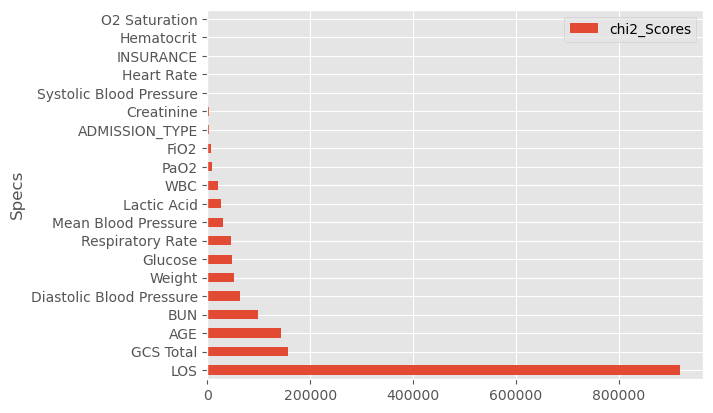

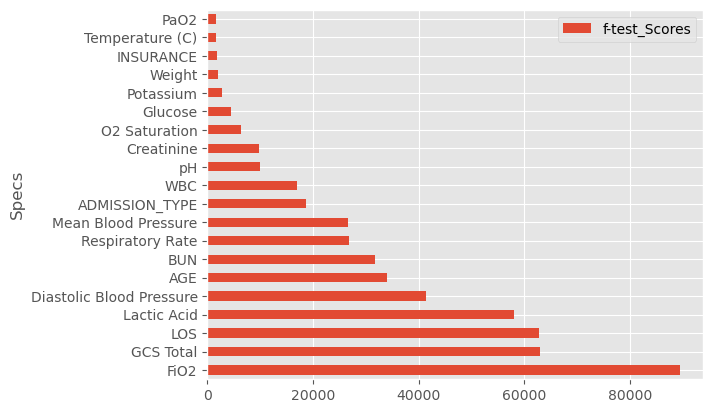

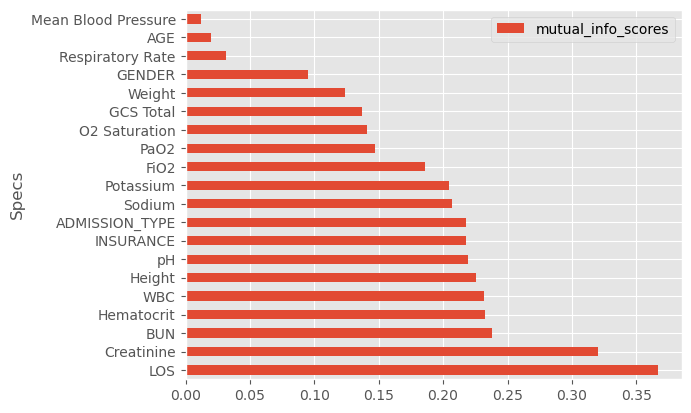

In [307]:
plt.figure(1, figsize=(10, 20))
for i in range(3):
    # plt.subplot(131+i)
    fs = featureScores.columns[i+1]
    best_features = featureScores.nlargest(20, fs)[['Specs', fs]]
    best_features.plot.barh('Specs');   # pands plot()

In [540]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(random_state=100, n_estimators=50, n_jobs=-1)

rfe_model = RFE(rfc, n_features_to_select = 20, step = 1)
rfe = rfe_model.fit(X, y.astype('int'))
rfe.support_   # rfe.get_support()

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False, False,  True, False,  True,  True,  True, False,
       False,  True,  True,  True,  True, False,  True,  True])

In [541]:
rfe.ranking_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 7, 6, 1, 2, 1, 1, 1, 5, 3, 1, 1, 1,
       1, 4, 1, 1])

In [542]:
print(X.columns)

Index(['LOS', 'GENDER', 'AGE', 'Heart Rate', 'O2 Saturation',
       'Respiratory Rate', 'Temperature (C)', 'Mean Blood Pressure',
       'Systolic Blood Pressure', 'Diastolic Blood Pressure', 'WBC', 'pH',
       'Glucose', 'Sodium', 'Potassium', 'Creatinine', 'BUN', 'Hematocrit',
       'Height', 'Weight', 'GCS Total', 'Lactic Acid', 'FiO2', 'PaO2',
       'ADMISSION_TYPE', 'INSURANCE'],
      dtype='object')


In [543]:
# Boolean‐mask approach (recommended)
mask = rfe.support_                   # e.g. array([ True, False, True, ... ])
selected_columns = X.columns[mask]    # Index([...names of the True cols...])

# Subset the DataFrame to only those columns
X_selected = X.loc[:, mask]

# or equivalently:
X= X[selected_columns]


# **Model Training - 2 Modalities**

In [544]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size= 0.2, random_state=42)

## **Random Forest**

Grid_Search

In [545]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import warnings
from sklearn.exceptions import DataConversionWarning


warnings.filterwarnings('ignore',
                        category=DataConversionWarning,
                        message='.*column-vector y.*')


rfc = RandomForestClassifier(random_state=42, n_jobs=-1)

param_grid = {
    "n_estimators":      [10, 20, 30, 40],
    "max_depth":         [None, 10, 20, 30],
    "min_samples_split": [4, 10, 15],
    "max_features":      ['sqrt', 'log2'],
    "bootstrap":         [True, False]
}

grid_search = GridSearchCV(
    estimator=rfc,
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)


Fitting 3 folds for each of 192 candidates, totalling 576 fits


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,),

Best Parameters: {'bootstrap': False, 'max_depth': None, 'max_features': 'log2', 'min_samples_split': 4, 'n_estimators': 40}
Best CV Accuracy: 0.9920942442241486


In [546]:
RFC = RandomForestClassifier(max_depth= None, max_features="log2", min_samples_split = 4, n_estimators= 40, random_state=42, n_jobs=-1, bootstrap = False)
RFC.fit(X_train, y_train)

RandomForestClassifier(bootstrap=False, max_features='log2',
                       min_samples_split=4, n_estimators=40, n_jobs=-1,
                       random_state=42)

In [547]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import roc_auc_score

y_predict_RFC = RFC.predict(X_test)

accuracy_RFC = accuracy_score(y_test, y_predict_RFC)
print("Accuracy rate for Random Forest Classifier:", accuracy_RFC)

auc_RFC = roc_auc_score(y_test, y_predict_RFC)
print(f"AUC = {auc_RFC:.3f}")

kappa_RFC = cohen_kappa_score(y_test, y_predict_RFC)
print(f"Cohen’s kappa for Random Forest Classifier: {kappa_RFC:.3f}")

report_RFC = classification_report(y_test, y_predict_RFC, digits=4)
print(report_RFC)




Accuracy rate for Random Forest Classifier: 0.995199763079832
AUC = 0.985
Cohen’s kappa for Random Forest Classifier: 0.981
              precision    recall  f1-score   support

           0     0.9948    0.9996    0.9972    520042
           1     0.9975    0.9712    0.9842     94511

    accuracy                         0.9952    614553
   macro avg     0.9961    0.9854    0.9907    614553
weighted avg     0.9952    0.9952    0.9952    614553



Text(0.5, 1.0, 'Normalized Confusion Matrix for Random Forest Classifier')

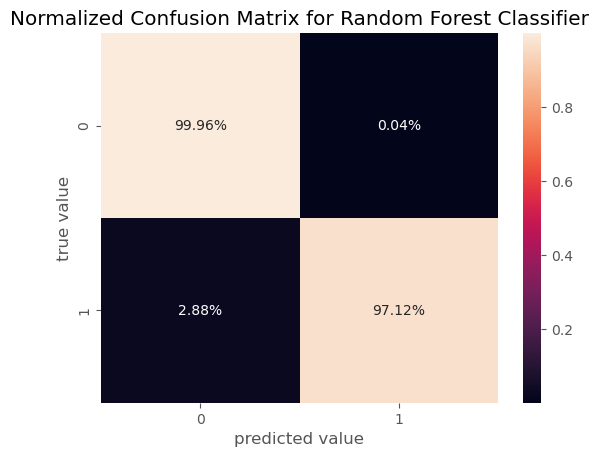

In [548]:
mat_RFC = confusion_matrix(y_test, y_predict_RFC, normalize='true')
sns.heatmap(mat_RFC, annot=True,fmt='.2%', cbar=True)
plt.xlabel('predicted value')
plt.ylabel('true value')
plt.title("Normalized Confusion Matrix for Random Forest Classifier")

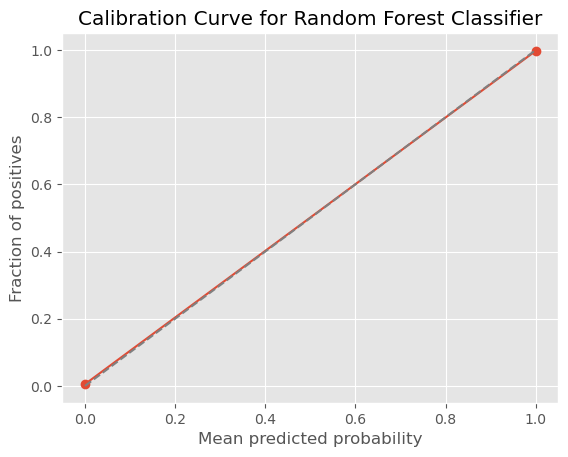

In [549]:
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(y_test, y_predict_RFC, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve for Random Forest Classifier')
plt.show()

## **Decision Tree Classifier**

Grid_search

In [550]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

DTC = DecisionTreeClassifier(random_state = 42)

param_grid = {
    'max_depth': [None, 5, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf':  [1, 2, 4, 10],          
    'max_features': [None, 'sqrt', 'log2'],
    'class_weight': [None, 'balanced']
}


grid_search = GridSearchCV(
    estimator = DTC,
    param_grid = param_grid,
    scoring='accuracy',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
print("Best parameter for Decision Tree Classifier", grid_search.best_params_)
print("Accuracy", grid_search.best_score_)

Fitting 3 folds for each of 576 candidates, totalling 1728 fits


/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameter for Decision Tree Classifier {'class_weight': 'balanced', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Accuracy 0.9848491320306776


In [551]:
from sklearn.tree import DecisionTreeClassifier
DTC = DecisionTreeClassifier(min_samples_split = 2, min_samples_leaf = 1, max_features = None, max_depth = None, class_weight = "balanced")
DTC.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced')

In [552]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import roc_auc_score

y_predict_DTC = DTC.predict(X_test)

accuracy_DTC = accuracy_score(y_test, y_predict_DTC)
print("Accuracy Rate for Decision Tree classifier:", accuracy_DTC)

auc_DTC = roc_auc_score(y_test, y_predict_DTC)
print(f"AUC = {auc_DTC:.3f}")

kappa_DTC = cohen_kappa_score(y_test, y_predict_DTC)
print(f"Cohen’s kappa for Decision Tree classifier: {kappa_DTC:.3f}")


report_DTC = classification_report(y_test, y_predict_DTC, digits=4)
print(report_DTC)



Accuracy Rate for Decision Tree classifier: 0.988749546418291
AUC = 0.978
Cohen’s kappa for Decision Tree classifier: 0.957
              precision    recall  f1-score   support

           0     0.9932    0.9935    0.9934    520042
           1     0.9643    0.9625    0.9634     94511

    accuracy                         0.9887    614553
   macro avg     0.9787    0.9780    0.9784    614553
weighted avg     0.9887    0.9887    0.9887    614553



Text(50.722222222222214, 0.5, 'True Value')

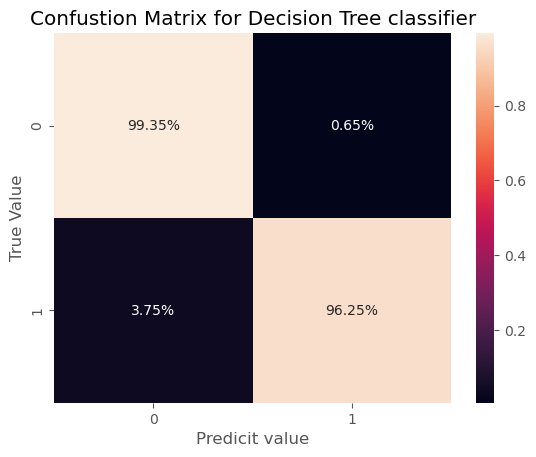

In [553]:
mat_DTC = confusion_matrix(y_test, y_predict_DTC, normalize = 'true')

sns.heatmap(mat_DTC, annot= True, fmt='.2%', cbar = True)
plt.title("Confustion Matrix for Decision Tree classifier")
plt.xlabel("Predicit value")
plt.ylabel("True Value")

Text(0.5, 1.0, 'Calibration Curve for Decision Tree Classifier')

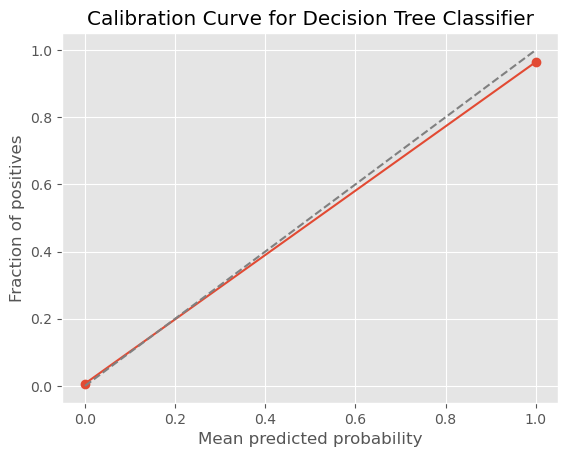

In [554]:
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(y_test, y_predict_DTC, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve for Decision Tree Classifier')

## **XGBoost**

Grid_Search

In [555]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# 1) Base estimator
XGB = XGBClassifier(
    tree_method="hist",      # fast histogram splits
    eval_metric="auc",       # use AUC for internal early‐stopping metric if you ever plug it in
    random_state=42,
    n_jobs=-1,
    verbosity=1
)

param_grid = {
    "n_estimators":      [200, 400, 600],
    "max_depth":         [4, 6, 8],
    "learning_rate":     [0.01, 0.1],
    "subsample":         [0.7, 0.8, 1.0],
    "colsample_bytree":  [0.7, 0.8, 1.0],
    "gamma":             [0, 0.25, 0.5]
}



grid_search = GridSearchCV(
    estimator=XGB,
    param_grid=param_grid,
    scoring="roc_auc",  # what you optimize
    cv=2,              # your cross‐validation splitter
    verbose=2,
    n_jobs=-1
)


grid_search.fit(X_train, y_train)


print("Best params:", grid_search.best_params_)
print("Best CV AUC:", grid_search.best_score_)


Fitting 2 folds for each of 486 candidates, totalling 972 fits
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=1.0; total time=  15.1s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=1.0; total time=  15.3s


/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=0.8; total time=  16.0s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=0.7; total time=  16.3s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=0.8; total time=  16.4s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=0.7; total time=  16.5s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=4, n_estimators=400, subsample=1.0; total time=  25.4s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=4, n_estimators=400, subsample=1.0; total time=  25.7s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=4, n_estimators=400, subsample=0.8; total time=  27.9s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=4, n_estimators=400, subsample=0.8; total time=  28.2s


In [560]:
from xgboost import XGBClassifier

XGB = XGBClassifier(
    colsmaple_bytree = 1.0,
    learning_rate = 0.1,
    gemma = 0.25,
    max_depth = 8, 
    n_estimators = 600,
    subsample = 0.7,
    eval_metric="logloss",
    random_state=42)

XGB.fit(X_train, y_train)

/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [01:42:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "colsmaple_bytree", "gemma" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, colsmaple_bytree=1.0, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=None, gemma=0.25, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=600, ...)

In [561]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import roc_auc_score


y_predict_XGB = XGB.predict(X_test)

accuracy_XGB = accuracy_score(y_test, y_predict_XGB)
print("Accuracy Rate for XGboost classifier: ", accuracy_XGB)


auc_XGB = roc_auc_score(y_test, y_predict_XGB)
print(f"AUC = {auc_XGB:.3f}")

kappa_XGB = cohen_kappa_score(y_test, y_predict_XGB)
print(f"Cohen’s kappa: {kappa_XGB:.3f}")


report_XGB = classification_report(y_test, y_predict_XGB, digits=4)
print(report_XGB)


Accuracy Rate for XGboost classifier:  0.9878318062071131
AUC = 0.962
Cohen’s kappa: 0.952
              precision    recall  f1-score   support

           0     0.9865    0.9993    0.9929    520042
           1     0.9956    0.9249    0.9590     94511

    accuracy                         0.9878    614553
   macro avg     0.9911    0.9621    0.9759    614553
weighted avg     0.9879    0.9878    0.9876    614553



Text(50.722222222222214, 0.5, 'True Value')

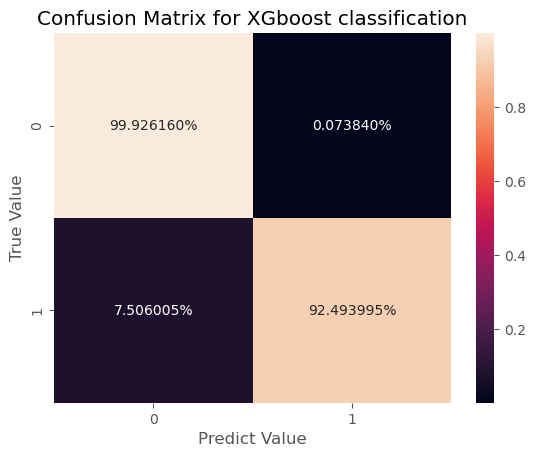

In [562]:
mat_XGB = confusion_matrix(y_test, y_predict_XGB, normalize = 'true')

sns.heatmap(mat_XGB, annot = True, fmt= '2%', cbar = True)
plt.title("Confusion Matrix for XGboost classification")
plt.xlabel("Predict Value")
plt.ylabel("True Value")

Text(0.5, 1.0, 'Calibration Curve for XGBoost')

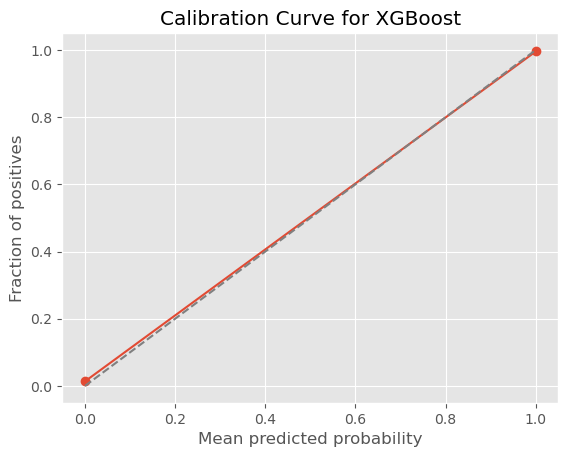

In [563]:
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(y_test, y_predict_XGB, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve for XGBoost')